# VAE clustering: Physiological Sepsis Phenotyping for 5-5min segments in Pitt Data 
## Stage 2: Data preprocessing and phenotype identification

# With limited dataset (when matched with target vectors)



In [1]:
# rm -rf ~/.cache

In [2]:
# %pip install scipy==1.11.4
# import tc_tabular_consensus_clusters_pipeline

In [1]:
import pandas as pd
from datetime import datetime
import os
import numpy as np
from scipy.io import loadmat
import glob
import json
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# Rest of the workflow is as follows:

In [4]:
#
'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

# ===== Step 1: Autoencoder Backbone =====
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        dims = [input_dim] + hidden_dims
        self.encoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.latent = nn.Linear(dims[-1], latent_dim)

    def forward(self, x):
        h = F.relu(self.encoder(x))
        z = self.latent(h)
        return z

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        dims = [latent_dim] + hidden_dims[::-1]
        self.decoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.output = nn.Linear(dims[-1], output_dim)

    def forward(self, z):
        h = F.relu(self.decoder(z))
        return self.output(h)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dims, input_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

# ===== Step 2: Deep Embedded Clustering Module =====
class DEC(nn.Module):
    def __init__(self, ae, n_clusters):
        super().__init__()
        self.ae = ae
        self.n_clusters = n_clusters
        self.cluster_centers = nn.Parameter(torch.Tensor(n_clusters, ae.encoder.latent.out_features))
        nn.init.xavier_uniform_(self.cluster_centers.data)

    def target_distribution(self, q):
        weight = q ** 2 / q.sum(0)
        return (weight.t() / weight.sum(1)).t()

    def soft_assign(self, z):
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q / q.sum(1, keepdim=True)
        return q

    def forward(self, x):
        _, z = self.ae(x)
        q = self.soft_assign(z)
        return q, z

# ===== Step 3: Training =====
def train_dec(model, data_tensor, n_clusters=4, pretrain_epochs=20, dec_epochs=50, batch_size=64):
    dataloader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.ae.parameters(), lr=1e-3)

    # --- Pretrain Autoencoder ---
    for epoch in range(pretrain_epochs):
        for batch in dataloader:
            x = batch[0]
            x_hat, _ = model.ae(x)
            loss = F.mse_loss(x_hat, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- Initialize Clusters ---
    with torch.no_grad():
        latent = model.ae.encoder(data_tensor)
    kmeans = KMeans(n_clusters=n_clusters, n_init=20)
    model.cluster_centers.data.copy_(torch.tensor(kmeans.fit(latent.detach().numpy()).cluster_centers_))

    # --- Train DEC ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(dec_epochs):
        for batch in dataloader:
            x = batch[0]
            q, z = model(x)
            p = model.target_distribution(q.detach())
            loss_kl = F.kl_div(q.log(), p, reduction='batchmean')
            x_hat, _ = model.ae(x)
            loss_recon = F.mse_loss(x_hat, x)
            loss = loss_kl + loss_recon
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

# ===== Step 4: Usage Example =====
# Assume `X_tensor` is a torch.FloatTensor of shape (N, 87) with snapshot physiomarkers
# input_dim = 87
# hidden_dims = [64, 32]
# latent_dim = 10
# n_clusters = 4

# ae = Autoencoder(input_dim, hidden_dims, latent_dim)
# dec = DEC(ae, n_clusters)
# dec = train_dec(dec, X_tensor, n_clusters=n_clusters)
# dec


from sklearn.datasets import make_blobs
import torch
import numpy as np

# Parameters
n_samples = 300
n_features = 87  # same as your physiomarker count
n_clusters = 4   # for 4 phenotypes
random_state = 42

# Generate synthetic data
X_np, y_true = make_blobs(n_samples=n_samples, centers=n_clusters, 
                          n_features=n_features, cluster_std=1.5, random_state=random_state)

# Convert to PyTorch tensor
X_tensor = torch.tensor(X_np, dtype=torch.float32)

input_dim = n_features
hidden_dims = [64, 32]
latent_dim = 10
n_clusters = 4

ae = Autoencoder(input_dim, hidden_dims, latent_dim)
dec = DEC(ae, n_clusters)
dec = train_dec(dec, X_tensor, n_clusters=n_clusters)



from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
X_pca = PCA(n_components=2).fit_transform(X_np)

# Plot ground truth clusters
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=20)
plt.title("Simulated Physiophenotypes (Ground Truth)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

'''
# end

'\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom sklearn.cluster import KMeans\nfrom torch.utils.data import DataLoader, TensorDataset\n\n# ===== Step 1: Autoencoder Backbone =====\nclass Encoder(nn.Module):\n    def __init__(self, input_dim, hidden_dims, latent_dim):\n        super().__init__()\n        dims = [input_dim] + hidden_dims\n        self.encoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])\n        self.latent = nn.Linear(dims[-1], latent_dim)\n\n    def forward(self, x):\n        h = F.relu(self.encoder(x))\n        z = self.latent(h)\n        return z\n\nclass Decoder(nn.Module):\n    def __init__(self, latent_dim, hidden_dims, output_dim):\n        super().__init__()\n        dims = [latent_dim] + hidden_dims[::-1]\n        self.decoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])\n        self.output = nn.Linear(dims[-1], output_dim)\n\n    def forward(self, z):\n        h = 

In [ ]:
AllSuperTable_1 = pd.read_csv('Data_folder/df_step1_physiomarkers_presepsis6hrs_5minWindow_new_v5.csv')
AllSuperTable_1.drop(columns=['Unnamed: 0'],axis=1,inplace=True)
AllSuperTable_1 

In [ ]:
AllSuperTable_perfect = AllSuperTable_1[AllSuperTable_1.status=='perfect']
AllSuperTable_perfect

In [7]:
del AllSuperTable_1

In [8]:
len(AllSuperTable_perfect.fin.unique()), len(AllSuperTable_perfect.studyID.unique())

(2199, 2130)

<Axes: >

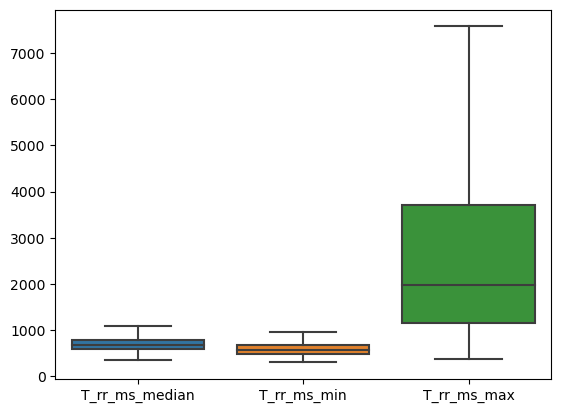

In [9]:
import seaborn as sns
sns.boxplot(AllSuperTable_perfect[['T_rr_ms_median', 'T_rr_ms_min', 'T_rr_ms_max']], showfliers=False)

In [ ]:
AllSuperTable_2 = AllSuperTable_perfect.drop_duplicates()
AllSuperTable_2.reset_index(drop=True, inplace=True)
AllSuperTable_2

In [11]:
del AllSuperTable_perfect

In [12]:
AllSuperTable_2[AllSuperTable_2.segmentID==0].shape, AllSuperTable_2[AllSuperTable_2.segmentID==0].fin.nunique()

((2195, 1351), 2195)

In [13]:
AllSuperTable_2.columns[:50]

Index(['Unnamed: 0.1', 'index', 'segmentID', 'waveID', 'fin', 'year_sepsis',
       'studyID', 't_origin', 't_sepsis', 'sofa', 'T_rr_ms_mean',
       'T_rr_ms_median', 'T_rr_ms_std', 'T_rr_ms_mad', 'T_rr_ms_iqr',
       'T_rr_ms_min', 'T_rr_ms_max', 'T_rr_ms_p25', 'T_rr_ms_p75',
       'T_rr_ms_skewness', 'T_rr_ms_kurtosis', 'T_rr_ms_entropy',
       'T_rr_ms_slope', 'T_rr_ms_autocorr_lag1', 'T_rr_ms_gini_index',
       'T_rr_ms_valid_n', 'HR_bpm_mean', 'HR_bpm_median', 'HR_bpm_std',
       'HR_bpm_mad', 'HR_bpm_iqr', 'HR_bpm_min', 'HR_bpm_max', 'HR_bpm_p25',
       'HR_bpm_p75', 'HR_bpm_skewness', 'HR_bpm_kurtosis', 'HR_bpm_entropy',
       'HR_bpm_slope', 'HR_bpm_autocorr_lag1', 'HR_bpm_gini_index',
       'HR_bpm_valid_n', 'edr_rate_Bpm_mean', 'edr_rate_Bpm_median',
       'edr_rate_Bpm_std', 'edr_rate_Bpm_mad', 'edr_rate_Bpm_iqr',
       'edr_rate_Bpm_min', 'edr_rate_Bpm_max', 'edr_rate_Bpm_p25'],
      dtype='object')

In [14]:
AllSuperTable_2.columns[50:]

Index(['edr_rate_Bpm_p75', 'edr_rate_Bpm_skewness', 'edr_rate_Bpm_kurtosis',
       'edr_rate_Bpm_entropy', 'edr_rate_Bpm_slope',
       'edr_rate_Bpm_autocorr_lag1', 'edr_rate_Bpm_gini_index',
       'edr_rate_Bpm_valid_n', 'atrialSys_phase_mean',
       'atrialSys_phase_median',
       ...
       'ShockIndex_p25', 'ShockIndex_p75', 'ShockIndex_skewness',
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'status'],
      dtype='object', length=1301)

In [15]:
AllSuperTable_2.fin.nunique()

2199

### Datatype handling

In [16]:
import re
'''Curation of studyID column if it carries "XXXX.0" sort of entries'''
def clean_mixed_column(val):
    # Convert to string
    val_str = str(val)
    
    # If it matches float with .0 (e.g., 1308267.0 or '1308267.0')
    if re.match(r'^\d+\.0$', val_str):
        return val_str.split('.')[0]  # Remove .0
    else:
        return val_str

AllSuperTable_2['studyID'] = AllSuperTable_2['studyID'].apply(clean_mixed_column)

In [17]:
AllSuperTable_2['fin'] = AllSuperTable_2['fin'].astype('int')
AllSuperTable_2['studyID'] = AllSuperTable_2['studyID'].astype('str')

In [18]:
AllSuperTable_2['t_sepsis'] = pd.to_datetime(AllSuperTable_2['t_sepsis'])

## Add qSOFAs as feature variable: qSOFA_sbp, qSOFA_rr, qSOFA_gcs

GCS < 15, Respiratory rate ≥ 22, Systolic BP ≤ 100

In [19]:
path = '../pitts_emr_data'

vitals_gcs = pd.read_csv(path + '/vitals_GCS_new.csv', low_memory=False)
vitals_rr = pd.read_csv(path + '/vitals_resp_rate.csv', low_memory=False)
vitals_sbp = pd.read_csv(path + '/vitals_sbp.csv', low_memory=False, on_bad_lines='skip')

In [20]:
# with open(path + '/vitals_sbp_new.csv', 'r') as f:
#     for i, line in enumerate(f):
#         if 2607000 <= i <= 2607015:
#             print(f"Line {i}: {line}")

In [21]:
# vitals4.shape, vitals7.shape, vitals8.shape

In [22]:
vitals_gcs['fin'] = vitals_gcs.FIN_study_id.astype('int')
vitals_gcs['studyID'] = vitals_gcs.study_id.astype('str')
vitals_gcs['chartdate'] = pd.to_datetime(vitals_gcs['chartdate'])

vitals_rr['fin'] = vitals_rr.FIN_study_id.astype('int')
vitals_rr['studyID'] = vitals_rr.study_id.astype('str')
vitals_rr['chartdate'] = pd.to_datetime(vitals_rr['chartdate'])

vitals_sbp['fin'] = vitals_sbp.FIN_study_id.astype('int')
vitals_sbp['studyID'] = vitals_sbp.study_id.astype('str')
vitals_sbp['chartdate'] = pd.to_datetime(vitals_sbp['chartdate'])

In [23]:
# v = [vitals4, vitals7, vitals8]
# v_matched = pd.DataFrame()
# for v_i in v:
#     v_i.reset_index(inplace=True, drop=True)
#     v_i['fin'] = v_i.FIN_study_id.values
#     v_i['studyID'] = v_i.study_id.values
#     v_i['chartdate'] = pd.to_datetime(v_i['chartdate'])
#     v_i_matched = AllSuperTable_2.merge(v_i[['fin','studyID','chartdate','result_val', 'result_unit', 
#                                  'Vitals']], on=['fin', 'studyID'], how='left')
#     v_i_matched = v_i_matched[~v_i_matched.Vitals.isnull()]
#     v_matched = pd.concat([v_matched, v_i_matched])
# v_matched.reset_index(inplace=True, drop=True)
# ## v_matched

In [24]:
# v = [vitals4, vitals7, vitals8]
# v_concat = pd.concat(v)

# v_concat.reset_index(inplace=True, drop=True)
# v_concat['fin'] = v_concat.FIN_study_id.values
# v_concat['studyID'] = v_concat.study_id.values
# v_concat['chartdate'] = pd.to_datetime(v_concat['chartdate'])
# v_concat

# v_matched = AllSuperTable_2.merge(v_concat[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 # 'Vitals']], on=['fin'], how='left')

In [25]:
vitals_gcs.fin.nunique(), vitals_rr.fin.nunique(), vitals_sbp.fin.nunique(), AllSuperTable_2.fin.nunique()

(18989, 20875, 20860, 2199)

In [26]:
vitals_gcs_matched = vitals_gcs[vitals_gcs.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_gcs_matched.shape

(162345, 10)

In [27]:
vitals_rr_matched = vitals_rr[vitals_rr.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_rr_matched.shape

(591215, 10)

In [28]:
vitals_sbp_matched = vitals_sbp[vitals_sbp.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_sbp_matched.shape

(538870, 10)

In [29]:
del vitals_gcs, vitals_rr, vitals_sbp
print("Unique FINs in AllSuperTable_2:", AllSuperTable_2['fin'].nunique())
print("Unique FINs in vitals_gcs_matched:", vitals_gcs_matched['fin'].nunique())
print("Unique FINs in vitals_rr_matched:", vitals_rr_matched['fin'].nunique())
print("Unique FINs in vitals_sbp_matched:", vitals_sbp_matched['fin'].nunique())

Unique FINs in AllSuperTable_2: 2199
Unique FINs in vitals_gcs_matched: 2067
Unique FINs in vitals_rr_matched: 2069
Unique FINs in vitals_sbp_matched: 2067


In [30]:
v_matched_gcs = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_gcs_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_gcs.shape

(2178791, 9)

In [31]:
v_matched_rr = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_rr_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_rr.shape

(8153084, 9)

In [32]:
v_matched_sbp = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_sbp_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_sbp.shape

(6889652, 9)

In [33]:
del vitals_gcs_matched, vitals_rr_matched, vitals_sbp_matched

In [34]:
# grouped = v_matched.groupby('Vitals')
# qSOFA_gcs = grouped.get_group('GCS')[['studyID','fin','chartdate','result_val']]
# qSOFA_gcs = qSOFA_gcs[qSOFA_gcs.result_val!=' ']

In [35]:
qSOFA_gcs = v_matched_gcs[['studyID_x','fin','chartdate','result_val']]
qSOFA_gcs['studyID'] = qSOFA_gcs['studyID_x'].astype('str')
qSOFA_gcs = qSOFA_gcs[qSOFA_gcs.result_val!=' ']
qSOFA_gcs['qSOFA_gcs'] = pd.Series(qSOFA_gcs['result_val'].astype('float') < 15, dtype=int)
qSOFA_gcs = qSOFA_gcs[['studyID', 'fin', 'chartdate', 'qSOFA_gcs']]
qSOFA_gcs.drop_duplicates(inplace=True)
qSOFA_gcs.reset_index(inplace=True, drop=True)

In [36]:
qSOFA_rr1 = v_matched_rr[['studyID_x','fin','chartdate','result_val']]
qSOFA_rr1['studyID'] = qSOFA_rr1['studyID_x'].astype('str')
qSOFA_rr1 = qSOFA_rr1[qSOFA_rr1.result_val!=' ']
qSOFA_rr1['qSOFA_rr'] = pd.Series(qSOFA_rr1['result_val'].astype('float') >= 22, dtype=int)
qSOFA_rr1 = qSOFA_rr1[['studyID', 'fin', 'chartdate', 'qSOFA_rr']]
qSOFA_rr1.drop_duplicates(inplace=True)
qSOFA_rr1.reset_index(inplace=True, drop=True)
qSOFA_rr = qSOFA_rr1.copy()

In [37]:
qSOFA_sbp1 = v_matched_sbp[['studyID_x','fin','chartdate','result_val']]
qSOFA_sbp1['studyID'] = qSOFA_sbp1['studyID_x'].astype('str')
qSOFA_sbp1 = qSOFA_sbp1[qSOFA_sbp1.result_val!=' ']
qSOFA_sbp1['qSOFA_sbp'] = pd.Series(qSOFA_sbp1['result_val'].astype('float') <= 100, dtype=int)
qSOFA_sbp1 = qSOFA_sbp1[['studyID', 'fin', 'chartdate', 'qSOFA_sbp']]
qSOFA_sbp1.drop_duplicates(inplace=True)
qSOFA_sbp1.reset_index(inplace=True, drop=True)
qSOFA_sbp = qSOFA_sbp1.copy()

In [38]:
# qSOFA_dbp = grouped.get_group('dbp')[['studyID','fin','chartdate','result_val']]
# qSOFA_dbp['dbp'] = qSOFA_dbp.result_val.values
# qSOFA_dbp = qSOFA_dbp[qSOFA_dbp.result_val!=' ']
# qSOFA_dbp.reset_index(inplace=True, drop=True)
# qSOFA_dbp.drop(columns=['result_val'], inplace=True)

# qSOFA_map = grouped.get_group('map')[['studyID','fin','chartdate','result_val']]
# qSOFA_map['map'] = qSOFA_map.result_val.values
# qSOFA_map = qSOFA_map[qSOFA_map.result_val!=' ']
# qSOFA_map.reset_index(inplace=True, drop=True)
# qSOFA_map.drop(columns=['result_val'], inplace=True)

# qSOFA_map_dbp = qSOFA_map.merge(qSOFA_dbp, on=['studyID','fin','chartdate'], how='left')
# qSOFA_map_dbp = qSOFA_map_dbp[~qSOFA_map_dbp.dbp.isnull()]
# qSOFA_map_dbp['sbp'] = (3*qSOFA_map_dbp['map'].astype('float')) - (2*qSOFA_map_dbp['dbp'].astype('float'))
# qSOFA_map_dbp['qSOFA_sbp'] = pd.Series(qSOFA_map_dbp['sbp']<=100, dtype=int)
# qSOFA_sbp = qSOFA_map_dbp[['studyID', 'fin', 'chartdate', 'qSOFA_sbp']]
# qSOFA_sbp.drop_duplicates(inplace=True)
# qSOFA_sbp.reset_index(inplace=True, drop=True)


In [39]:
AllSuperTable_2.fin.nunique(), qSOFA_sbp.fin.nunique(), qSOFA_rr.fin.nunique(), qSOFA_gcs.fin.nunique()

(2199, 2067, 2069, 2067)

In [40]:
sbp_rr = qSOFA_sbp.merge(qSOFA_rr, on=['studyID', 'fin', 'chartdate'], how='left')
sbp_rr_gcs = sbp_rr.merge(qSOFA_gcs, on=['studyID', 'fin', 'chartdate'], how='left')
sbp_rr_gcs.drop_duplicates(inplace=True)
sbp_rr_gcs.columns, sbp_rr_gcs.shape

(Index(['studyID', 'fin', 'chartdate', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs'], dtype='object'),
 (534140, 6))

In [41]:
AllSuperTable_wqSOFA = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(sbp_rr_gcs, on=['studyID', 'fin'], how='left')
#AllSuperTable_wqSOFA = AllSuperTable_wqSOFA[~AllSuperTable_wqSOFA.qSOFA_total.isnull()]

In [ ]:
AllSuperTable_wqSOFA

In [43]:
AllSuperTable_2[['fin','segmentID']].drop_duplicates().shape, AllSuperTable_2.shape, #AllSuperTable_wqSOFA.fin.nunique()

((29727, 2), (29727, 1351))

In [44]:
# for individual encounter/fin and a given segmentID
def qSOFA_nearest_to_segment(df):
    df['diff_date'] = df['chartdate'] - df['t_sepsis'] - (df['segmentID']*pd.Timedelta('0 days 00:05:00'))
    if df[['qSOFA_sbp','qSOFA_rr','qSOFA_gcs']].isnull().all().all():
        mf = df.iloc[0]
    else: 
        if (df['diff_date']>=pd.Timedelta(0)).all(): # if all true
            minD = df['diff_date'].min() #Latest to tsepsis
        else:
            minD = df['diff_date'][df['diff_date']<pd.Timedelta(0)].max() #Latest to tsepsis
        mf = df.iloc[np.where(df['diff_date']==minD)[0][0]]
    return mf    

In [45]:
df_all = pd.DataFrame([])
for i in tqdm(range(AllSuperTable_2.shape[0])):
    fin_i = AllSuperTable_2.iloc[i]['fin']
    segmentID_i = AllSuperTable_2.iloc[i]['segmentID']
    df_fin = AllSuperTable_wqSOFA[AllSuperTable_wqSOFA.fin==fin_i]
    df_fin = df_fin.ffill()
    df_fin = df_fin.bfill()
    df_fin_seg = df_fin[df_fin.segmentID==segmentID_i]
    df_row = pd.DataFrame(qSOFA_nearest_to_segment(df_fin_seg)).T
    df_all = pd.concat([df_all, df_row])

100%|██████████| 29727/29727 [07:47<00:00, 63.59it/s]


In [ ]:
df_all.reset_index(inplace=True, drop=True)
df_all['qSOFA_total'] = df_all['qSOFA_sbp'] + df_all['qSOFA_rr'] + df_all['qSOFA_gcs'] 
df_all_2 = df_all[['studyID','fin','segmentID','t_sepsis','qSOFA_sbp','qSOFA_rr','qSOFA_gcs','qSOFA_total']]
df_all_2

In [47]:
df_all_2['t_sepsis'] = pd.to_datetime(df_all_2['t_sepsis'])
df_all_2.qSOFA_total.isnull().sum(), df_all_2.qSOFA_total.value_counts()

(1408,
 qSOFA_total
 1.0    13471
 2.0     7896
 0.0     5646
 3.0     1306
 Name: count, dtype: int64)

In [48]:
AllSuperTable_2new = AllSuperTable_2.merge(df_all_2, on=['studyID','fin','segmentID','t_sepsis'], how='left')

In [ ]:
AllSuperTable_2new

In [50]:
AllSuperTable_2new.drop(columns = ['status'], axis=1, inplace=True)

In [51]:
AllSuperTable_2new.columns

Index(['Unnamed: 0.1', 'index', 'segmentID', 'waveID', 'fin', 'year_sepsis',
       'studyID', 't_origin', 't_sepsis', 'sofa',
       ...
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total'],
      dtype='object', length=1354)

In [52]:
AllSuperTable_2new[~AllSuperTable_2new.qSOFA_gcs.isnull()].fin.nunique()

2056

In [53]:
AllSuperTable_2new.columns[7:]

Index(['t_origin', 't_sepsis', 'sofa', 'T_rr_ms_mean', 'T_rr_ms_median',
       'T_rr_ms_std', 'T_rr_ms_mad', 'T_rr_ms_iqr', 'T_rr_ms_min',
       'T_rr_ms_max',
       ...
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total'],
      dtype='object', length=1347)

# Outlier Rejection: using IQR method (considering non-normal nature of feature data)

In [54]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum()

12215349

In [55]:
AllSuperTable_2new.DN_exists.isnull().sum()

5793

In [56]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,:32]

,T_rr_ms_mean,T_rr_ms_median,T_rr_ms_std,T_rr_ms_mad,T_rr_ms_iqr,T_rr_ms_min,T_rr_ms_max,T_rr_ms_p25,T_rr_ms_p75,T_rr_ms_skewness,...,HR_bpm_max,HR_bpm_p25,HR_bpm_p75,HR_bpm_skewness,HR_bpm_kurtosis,HR_bpm_entropy,HR_bpm_slope,HR_bpm_autocorr_lag1,HR_bpm_gini_index,HR_bpm_valid_n
count,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,...,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000
mean,806.025151,715.565857,288.509281,129.734947,151.571660,584.755079,3056.864712,679.133591,830.705251,5.492338,...,109.427205,82.861366,92.803898,-2.747096,33.680083,1.084809,0.000681,0.118970,0.064157,371.003348
std,409.383431,247.707839,539.597344,299.404177,450.247406,152.052677,4040.113291,165.024941,540.909342,5.569542,...,27.788184,23.864192,20.125731,4.311530,68.926202,0.652590,0.284781,0.290818,0.068101,146.186375
min,365.452876,353.000000,0.725174,0.487805,0.000000,301.000000,380.000000,316.000000,357.000000,-18.074505,...,25.125628,3.122236,17.162471,-25.250719,-1.999501,0.009700,-12.822271,-0.996867,0.000777,4.000000
25%,614.032990,590.000000,48.440034,14.561644,12.000000,471.000000,1144.000000,569.000000,613.750000,1.661942,...,89.552239,69.524913,78.636959,-4.540452,-0.000037,0.562836,-0.005669,-0.038343,0.013963,285.000000
50%,720.089372,680.000000,148.176251,43.687500,23.000000,571.000000,1970.000000,660.000000,713.000000,3.847367,...,105.078809,84.151473,90.909091,-1.384020,5.376128,1.001010,-0.000157,0.052260,0.035246,390.000000
75%,896.604230,793.000000,355.214855,144.596386,80.000000,670.000000,3718.000000,763.000000,863.000000,8.330827,...,127.388535,97.759723,105.448155,-0.138513,33.342016,1.710493,0.005475,0.214309,0.100865,472.000000
max,12478.800000,7794.000000,13899.762873,9447.200000,16021.000000,2388.000000,119345.000000,3496.000000,19217.000000,27.318083,...,199.335548,168.067227,189.873418,21.865189,682.633643,2.274316,24.887594,0.996584,0.586842,817.000000


In [57]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,32:50]

,edr_rate_Bpm_mean,edr_rate_Bpm_median,edr_rate_Bpm_std,edr_rate_Bpm_mad,edr_rate_Bpm_iqr,edr_rate_Bpm_min,edr_rate_Bpm_max,edr_rate_Bpm_p25,edr_rate_Bpm_p75,edr_rate_Bpm_skewness,edr_rate_Bpm_kurtosis,edr_rate_Bpm_entropy,edr_rate_Bpm_slope,edr_rate_Bpm_autocorr_lag1,edr_rate_Bpm_gini_index,edr_rate_Bpm_valid_n,atrialSys_phase_mean,atrialSys_phase_median
count,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,21777.000000,22101.000000,22101.000000
mean,17.060392,16.536058,5.591293,4.234913,7.059912,7.879220,35.566199,13.061490,20.121401,0.833497,2.112762,1.863762,0.000837,0.024873,0.176130,65.721357,145.429443,143.987851
std,2.261769,2.709334,1.629246,1.126218,2.386610,1.912837,11.634978,2.564578,2.797120,0.996061,5.632666,0.285572,0.524841,0.177520,0.044293,19.535557,39.703881,40.897427
min,6.746121,6.250108,0.006755,0.006755,0.006755,1.698658,8.913980,5.416848,7.617275,-5.313071,-2.000000,0.229523,-19.743818,-0.879487,0.000291,2.000000,77.926509,3.000000
25%,15.575244,14.862522,4.704713,3.609260,5.660377,6.780427,29.083858,11.162791,18.348624,0.303265,-0.361956,1.753672,-0.026526,-0.081917,0.153549,60.000000,124.236957,122.000000
50%,17.093590,16.551971,5.516075,4.267721,7.090697,7.692308,33.688939,13.008167,20.140987,0.682116,0.473430,1.935607,0.000481,0.024762,0.177183,70.000000,138.166172,137.000000
75%,18.532235,18.192844,6.383583,4.930167,8.499540,8.693132,39.241334,14.646729,21.937843,1.157555,2.181971,2.057275,0.028070,0.138074,0.203492,78.000000,158.231481,157.000000
max,27.643192,29.268634,21.615115,11.218451,18.626746,26.513478,123.966942,26.611566,31.429234,9.236552,91.931064,2.287840,17.854068,0.825790,0.423617,123.000000,923.181818,998.000000


In [58]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,50:85]

,atrialSys_phase_std,atrialSys_phase_mad,atrialSys_phase_iqr,atrialSys_phase_min,atrialSys_phase_max,atrialSys_phase_p25,atrialSys_phase_p75,atrialSys_phase_skewness,atrialSys_phase_kurtosis,atrialSys_phase_entropy,...,ventSys_phase_entropy,ventSys_phase_slope,ventSys_phase_autocorr_lag1,ventSys_phase_gini_index,ventSys_phase_valid_n,P_duration_mean,P_duration_median,P_duration_std,P_duration_mad,P_duration_iqr
count,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,...,22030.000000,22030.000000,22030.000000,22030.000000,22030.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000
mean,15.187569,10.617542,17.018981,108.524863,205.276503,136.173703,153.192684,0.933493,12.345051,1.494481,...,0.770589,52.974009,0.037577,0.271737,331.983749,66.826343,64.945229,19.945300,14.566461,24.259162
std,18.188010,13.531291,25.563191,30.170872,80.015867,37.623059,47.035828,2.573426,31.811004,0.469646,...,0.509012,3947.993728,0.131657,0.198456,150.433592,22.825513,25.627805,10.450473,8.607913,18.332733
min,0.497494,0.250000,0.000000,1.000000,82.000000,2.000000,79.000000,-19.243986,-1.977069,0.012309,...,0.010147,-116134.500000,-0.874065,0.001559,2.000000,20.160271,18.000000,0.730150,0.493225,0.000000
25%,5.145126,3.538618,5.000000,87.000000,154.000000,116.000000,129.000000,-0.179256,-0.117094,1.166143,...,0.355713,-0.121786,-0.028669,0.077915,242.000000,50.725086,45.000000,12.701586,8.312500,9.000000
50%,9.070161,5.942308,9.000000,106.000000,189.000000,131.000000,145.000000,0.504628,1.923838,1.580454,...,0.720884,0.002348,0.012848,0.259756,352.000000,64.489676,62.000000,19.022107,13.607623,21.000000
75%,19.911886,13.302326,20.000000,125.000000,238.000000,150.000000,167.000000,1.604557,9.867340,1.873368,...,1.090368,0.135005,0.089698,0.438986,438.750000,79.597633,80.000000,26.155285,19.862416,35.000000
max,413.714421,370.896552,783.500000,616.000000,1542.000000,910.000000,1207.000000,22.515780,529.454676,2.291163,...,2.266579,264489.000000,0.848662,0.893243,796.000000,410.100000,436.000000,204.014415,162.678571,381.250000


In [59]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,85:100]

,P_duration_min,P_duration_max,P_duration_p25,P_duration_p75,P_duration_skewness,P_duration_kurtosis,P_duration_entropy,P_duration_slope,P_duration_autocorr_lag1,P_duration_gini_index,P_duration_valid_n,QRS_duration_mean,QRS_duration_median,QRS_duration_std,QRS_duration_mad
count,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22101.000000,22088.000000,22088.000000,22088.000000,22088.000000
mean,27.450930,138.374236,53.629202,77.888365,0.674560,4.876127,1.603384,-0.001708,0.073391,0.162170,371.243292,102.725951,98.766661,28.102361,20.871945
std,15.374372,47.256983,23.479738,27.648128,1.703797,14.522984,0.377882,0.227156,0.152882,0.080219,145.035253,37.965856,39.816279,16.057853,13.280477
min,6.000000,31.000000,15.000000,20.000000,-17.200708,-1.970936,0.023267,-8.791176,-0.765560,0.005621,7.000000,36.736434,37.000000,0.000000,0.000000
25%,19.000000,108.000000,35.000000,58.000000,-0.170073,-0.306048,1.384120,-0.010394,-0.014841,0.097811,286.000000,74.873992,71.000000,17.448157,11.911985
50%,23.000000,132.000000,49.000000,75.000000,0.633771,1.101639,1.677713,-0.000164,0.042445,0.168338,389.000000,96.666783,92.000000,27.311662,20.000000
75%,30.000000,159.000000,68.000000,94.000000,1.406865,4.574423,1.889315,0.010596,0.127197,0.219249,471.000000,123.335470,119.500000,35.858541,28.127349
max,343.000000,876.000000,409.500000,464.500000,19.526296,417.266811,2.266963,6.531708,0.963523,0.488310,802.000000,817.766667,992.500000,261.848258,235.650350


In [60]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,100:]

,QRS_duration_iqr,QRS_duration_min,QRS_duration_max,QRS_duration_p25,QRS_duration_p75,QRS_duration_skewness,QRS_duration_kurtosis,QRS_duration_entropy,QRS_duration_slope,QRS_duration_autocorr_lag1,...,ShockIndex_max,ShockIndex_p25,ShockIndex_p75,ShockIndex_skewness,ShockIndex_kurtosis,ShockIndex_entropy,ShockIndex_slope,ShockIndex_autocorr_lag1,ShockIndex_gini_index,ShockIndex_valid_n
count,22088.000000,22088.000000,22088.000000,22088.000000,22088.000000,22033.000000,22033.000000,22038.000000,22038.000000,22033.000000,...,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000,2508.000000
mean,36.675525,55.534136,190.139488,82.696860,119.372385,0.904285,5.199328,1.518712,-0.025669,0.033094,...,1.365716,0.757847,0.850799,1.157417,18.905357,1.379862,0.000064,0.197282,0.058046,389.403509
std,29.364961,23.011136,73.150343,33.640235,48.336330,1.885694,21.380028,0.445615,2.332047,0.123633,...,0.739706,0.216758,0.271212,3.042524,36.801914,0.504230,0.001336,0.353458,0.055101,145.073135
min,0.000000,13.000000,40.000000,23.000000,38.000000,-13.293501,-2.000000,0.000000,-121.000000,-0.724975,...,0.366682,0.061970,0.161258,-10.870544,-1.974310,0.018426,-0.015365,-0.857394,0.003240,5.000000
25%,14.750000,42.000000,146.000000,56.000000,85.000000,0.052741,-0.746918,1.239458,-0.019023,-0.027010,...,0.835890,0.618034,0.663634,-0.262432,0.275295,1.003614,-0.000057,-0.075811,0.021832,345.000000
50%,34.000000,49.000000,183.000000,78.000000,112.000000,0.636762,0.292207,1.605648,-0.001059,0.026154,...,1.116469,0.729297,0.810580,0.491805,5.175160,1.367779,0.000005,0.158787,0.038551,422.000000
75%,52.000000,63.000000,227.000000,99.000000,145.000000,1.392179,3.258315,1.872598,0.013355,0.088740,...,1.713895,0.894484,0.972558,2.186615,18.603299,1.860412,0.000079,0.453128,0.076945,483.000000
max,482.500000,588.000000,1133.000000,634.000000,999.000000,22.992809,586.351495,2.272385,115.000000,0.882567,...,5.000913,1.818338,2.024489,18.624460,353.438156,2.263568,0.041293,0.984824,0.442989,727.000000


<Axes: >

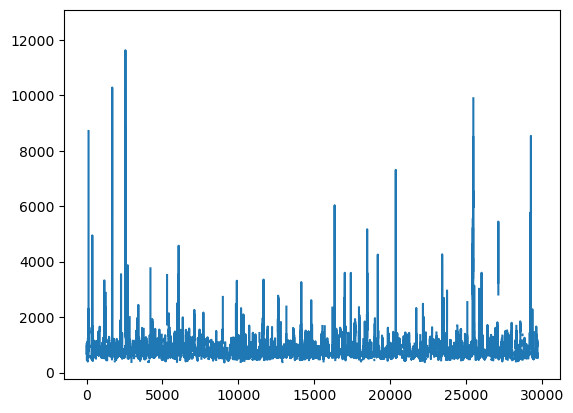

In [61]:
AllSuperTable_2new.T_rr_ms_mean.plot()

<Axes: >

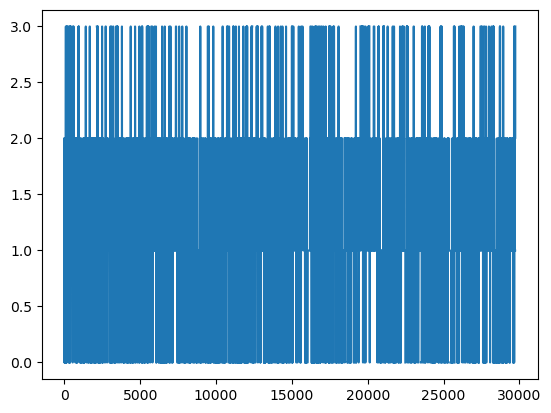

In [62]:
AllSuperTable_2new.qSOFA_total.plot()

In [63]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum(), AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].shape

(12215349, (29727, 1344))

In [64]:
AllSuperTable_2new = AllSuperTable_2new.replace([np.inf, -np.inf], np.nan)
# AllSuperTable_2['hrv_dfa_alpha2'] = AllSuperTable_2['hrv_dfa_alpha2'].apply(lambda x: np.nan if x == '[]' else x).astype(float)


In [65]:
AllSuperTable_2new.columns[9:]

Index(['sofa', 'T_rr_ms_mean', 'T_rr_ms_median', 'T_rr_ms_std', 'T_rr_ms_mad',
       'T_rr_ms_iqr', 'T_rr_ms_min', 'T_rr_ms_max', 'T_rr_ms_p25',
       'T_rr_ms_p75',
       ...
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total'],
      dtype='object', length=1345)

In [66]:
'''
Don't do the outlier-rejection in categorial and ordinal numeric variables

DN_exists, ppg_class, qSOFA_xx
'''
for i in AllSuperTable_2new.loc[:,'T_rr_ms_mean':'ShockIndex_valid_n'].columns: #ShockIndex
    if (i!='DN_exists') and (i!='ppg_class'):
        print(i)
        percentile25 = AllSuperTable_2new[i].quantile(0.25)
        percentile75 = AllSuperTable_2new[i].quantile(0.75)
        iqr = percentile75 - percentile25
        upper_limit = percentile75 + 1.5 * iqr
        lower_limit = percentile25 - 1.5 * iqr
        
        ### METHODS: Trimming or Caping or Replacing by nans
        ### Selected "Replacing by nans" method  
        uL = np.where(AllSuperTable_2new[i] > upper_limit)[0]
        lL = np.where(AllSuperTable_2new[i] < lower_limit)[0]
        
        AllSuperTable_2new.loc[uL,i] = np.nan
        AllSuperTable_2new.loc[lL,i] = np.nan



T_rr_ms_mean
T_rr_ms_median
T_rr_ms_std
T_rr_ms_mad
T_rr_ms_iqr
T_rr_ms_min
T_rr_ms_max
T_rr_ms_p25
T_rr_ms_p75
T_rr_ms_skewness
T_rr_ms_kurtosis
T_rr_ms_entropy
T_rr_ms_slope
T_rr_ms_autocorr_lag1
T_rr_ms_gini_index
T_rr_ms_valid_n
HR_bpm_mean
HR_bpm_median
HR_bpm_std
HR_bpm_mad
HR_bpm_iqr
HR_bpm_min
HR_bpm_max
HR_bpm_p25
HR_bpm_p75
HR_bpm_skewness
HR_bpm_kurtosis
HR_bpm_entropy
HR_bpm_slope
HR_bpm_autocorr_lag1
HR_bpm_gini_index
HR_bpm_valid_n
edr_rate_Bpm_mean
edr_rate_Bpm_median
edr_rate_Bpm_std
edr_rate_Bpm_mad
edr_rate_Bpm_iqr
edr_rate_Bpm_min
edr_rate_Bpm_max
edr_rate_Bpm_p25
edr_rate_Bpm_p75
edr_rate_Bpm_skewness
edr_rate_Bpm_kurtosis
edr_rate_Bpm_entropy
edr_rate_Bpm_slope
edr_rate_Bpm_autocorr_lag1
edr_rate_Bpm_gini_index
edr_rate_Bpm_valid_n
atrialSys_phase_mean
atrialSys_phase_median
atrialSys_phase_std
atrialSys_phase_mad
atrialSys_phase_iqr
atrialSys_phase_min
atrialSys_phase_max
atrialSys_phase_p25
atrialSys_phase_p75
atrialSys_phase_skewness
atrialSys_phase_kurtosis
atr

In [67]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum()

13773833

<Axes: >

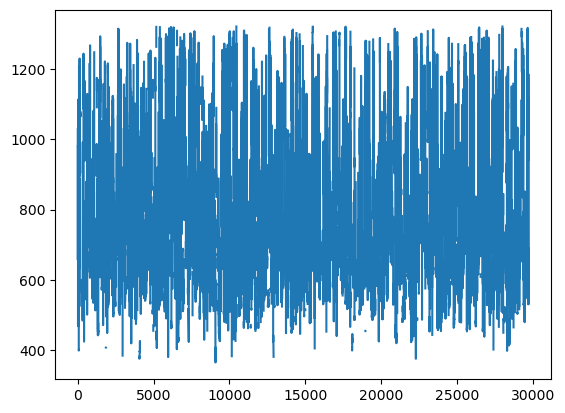

In [68]:
AllSuperTable_2new.T_rr_ms_mean.plot()

In [69]:
AllSuperTable_2new.reset_index(inplace=True, drop=True)
AllSuperTable_2new.shape

(29727, 1354)

In [70]:
# df_Sepsis_demo.reset_index(inplace=True, drop=True)

In [71]:
AllSuperTable_2new.columns[:100]

Index(['Unnamed: 0.1', 'index', 'segmentID', 'waveID', 'fin', 'year_sepsis',
       'studyID', 't_origin', 't_sepsis', 'sofa', 'T_rr_ms_mean',
       'T_rr_ms_median', 'T_rr_ms_std', 'T_rr_ms_mad', 'T_rr_ms_iqr',
       'T_rr_ms_min', 'T_rr_ms_max', 'T_rr_ms_p25', 'T_rr_ms_p75',
       'T_rr_ms_skewness', 'T_rr_ms_kurtosis', 'T_rr_ms_entropy',
       'T_rr_ms_slope', 'T_rr_ms_autocorr_lag1', 'T_rr_ms_gini_index',
       'T_rr_ms_valid_n', 'HR_bpm_mean', 'HR_bpm_median', 'HR_bpm_std',
       'HR_bpm_mad', 'HR_bpm_iqr', 'HR_bpm_min', 'HR_bpm_max', 'HR_bpm_p25',
       'HR_bpm_p75', 'HR_bpm_skewness', 'HR_bpm_kurtosis', 'HR_bpm_entropy',
       'HR_bpm_slope', 'HR_bpm_autocorr_lag1', 'HR_bpm_gini_index',
       'HR_bpm_valid_n', 'edr_rate_Bpm_mean', 'edr_rate_Bpm_median',
       'edr_rate_Bpm_std', 'edr_rate_Bpm_mad', 'edr_rate_Bpm_iqr',
       'edr_rate_Bpm_min', 'edr_rate_Bpm_max', 'edr_rate_Bpm_p25',
       'edr_rate_Bpm_p75', 'edr_rate_Bpm_skewness', 'edr_rate_Bpm_kurtosis',
       'e

In [72]:
AllSuperTable_2new.columns[100:200]

Index(['P_duration_kurtosis', 'P_duration_entropy', 'P_duration_slope',
       'P_duration_autocorr_lag1', 'P_duration_gini_index',
       'P_duration_valid_n', 'QRS_duration_mean', 'QRS_duration_median',
       'QRS_duration_std', 'QRS_duration_mad', 'QRS_duration_iqr',
       'QRS_duration_min', 'QRS_duration_max', 'QRS_duration_p25',
       'QRS_duration_p75', 'QRS_duration_skewness', 'QRS_duration_kurtosis',
       'QRS_duration_entropy', 'QRS_duration_slope',
       'QRS_duration_autocorr_lag1', 'QRS_duration_gini_index',
       'QRS_duration_valid_n', 'T_duration_mean', 'T_duration_median',
       'T_duration_std', 'T_duration_mad', 'T_duration_iqr', 'T_duration_min',
       'T_duration_max', 'T_duration_p25', 'T_duration_p75',
       'T_duration_skewness', 'T_duration_kurtosis', 'T_duration_entropy',
       'T_duration_slope', 'T_duration_autocorr_lag1', 'T_duration_gini_index',
       'T_duration_valid_n', 'pr_interval_ms_mean', 'pr_interval_ms_median',
       'pr_interval_ms_s

In [73]:
AllSuperTable_2new.columns[200:]

Index(['st_segment_ms_gini_index', 'st_segment_ms_valid_n',
       'qt_interval_ms_mean', 'qt_interval_ms_median', 'qt_interval_ms_std',
       'qt_interval_ms_mad', 'qt_interval_ms_iqr', 'qt_interval_ms_min',
       'qt_interval_ms_max', 'qt_interval_ms_p25',
       ...
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total'],
      dtype='object', length=1154)

In [74]:
df_Sepsis_final = AllSuperTable_2new.copy()



# [['waveID', 'fin', 'segmentID', 'year_sepsis', 'studyID', 't_origin',
#        't_sepsis', 'sofa', 'DN_exists', 'ppg_class', 'T_rr_ms', 'HR_bpm', 'edr_rate_Bpm',
#        'atrialSys_phase', 'ventSys_phase', 'P_duration', 'QRS_duration',
#        'T_duration', 'pr_interval_ms', 'pr_segment_ms', 'st_interval_ms',
#        'st_segment_ms', 'qt_interval_ms', 'qtc_interval_ms',
#        'ecgBeatCenterFreq', 'ecgInterbeat_eigval1', 'ecgInterbeat_eigval2',
#        'ecgInterbeat_eigval3', 'HRV_rqa_REC', 'HRV_rqa_DET', 'HRV_rqa_LAM',
#        'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
#        'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
#        'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
#        'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
#        'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
#        'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
#        'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2',
#        'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP',
#        'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI',
#        'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d',
#        'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd',
#        'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width',
#        'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean',
#        'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta',
#        'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Fluctuation', 
#        'HRV_MFDFA_alpha1_Increment', 'HRV_DFA_alpha2',
#        'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak',
#        'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max',
#        'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry',
#        'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment',
#        'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn',
#        'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC',
#        'MSE_0', 'MSE_1', 'MSE_2', 'MSE_3', 'MSE_4', 'MSE_5', 'MSE_6', 'MSE_7',
#        'MSE_8', 'MSE_9', 'MSE_10', 'MSE_11', 'MSE_12', 'MSE_13', 'MSE_14',
#        'MSE_15', 'MSE_16', 'MSE_17', 'MSE_18', 'MSE_19', 'AUC_pulse_nu',
#        'AUC_sys_nu', 'AUC_dias_nu', 'IPA', 'AUCow_nu', 'AUCwo_nu', 'AUCos_nu',
#        'AUCso_nu', 'Tsys_ms', 'Tdias_ms', 'T_ow_ms', 'T_wo_ms', 'T_os_ms',
#        'T_so_ms', 'T_so_cd_ms', 'A_AC', 'A_off', 'A_sp', 'A_dn',
#        'Ton_off_ms', 'Tsp_sp_ms', 'PR', 'mean_slope_os', 'mean_slope_so',
#        'Delta_T_sd', 'RI', 'SI', 'Delta_A_dn_dp', 'T_dn_dp_ms',
#        'max_upslope', 'pat_ms', 'dpat_ms', 'Delta_A_sp_sp',
#        'Augmentation_index', 'center_freq_ppg_Hz', 'mean_ppg', 'median_ppg',
#        'variance_ppg', 'skewness_ppg', 'kurtosis_ppg', 'std_ppg',
#        'entropy_ppg', 'energy_ppg', 'PW_10', 'PW_25', 'PW_33', 'PW_50',
#        'PW_66', 'PW_75', 'ppgBeatCenterFreq', 'ppgInterbeat_eigval1',
#        'ppgInterbeat_eigval2', 'ppgInterbeat_eigval3', 'insp_time', 'exp_time',
#        'insp_exp_ratio', 'resp_width_PPresp_s', 'resp_rate_Bpm', 'qSOFA_sbp', 'qSOFA_rr',
#        'qSOFA_gcs', 'qSOFA_total', 'SBP', 'DBP', 'HR_ABP', 
#        'MAP', 'PP_ABP', 'CO', 'TPR','ShockIndex']]
       
       

In [ ]:
df_Sepsis_final

In [76]:
# df_Sepsis_demo['csn'].equals(df_Sepsis_final['csn'])

In [77]:
df_Sepsis_final.ppg_class.unique()

array(['Class3', nan, 'Class2', 'Class1'], dtype=object)

# Step 1: Data Preprocessing (unimputed data)

In [78]:
df_Sepsis_final.replace([np.inf, -np.inf], np.nan, inplace=True)

In [79]:
# pip install seaborn

In [80]:
# df_Sepsis_final.shape, len(df_Sepsis_final.waveID.unique()), len(df_Sepsis_final.csn.unique()), len(df_Sepsis_final.pat_id.unique()), df_Sepsis_final.year.unique()



In [81]:
df_Sepsis_final.columns

Index(['Unnamed: 0.1', 'index', 'segmentID', 'waveID', 'fin', 'year_sepsis',
       'studyID', 't_origin', 't_sepsis', 'sofa',
       ...
       'ShockIndex_kurtosis', 'ShockIndex_entropy', 'ShockIndex_slope',
       'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total'],
      dtype='object', length=1354)

In [82]:
df_Sepsis_final.loc[:,'T_rr_ms_mean':].isnull().sum()

T_rr_ms_mean           8723
T_rr_ms_median         8290
T_rr_ms_std            8958
T_rr_ms_mad            9667
T_rr_ms_iqr           11358
                      ...  
ShockIndex_valid_n    27483
qSOFA_sbp              1275
qSOFA_rr               1287
qSOFA_gcs              1401
qSOFA_total            1408
Length: 1344, dtype: int64

In [83]:
df_Sepsis_final.DN_exists.value_counts()

DN_exists
True     20941
False     2993
Name: count, dtype: int64

In [84]:
AllSuperTable_2[AllSuperTable_2.T_rr_ms_median.isnull()][['index','T_rr_ms_median','edr_rate_Bpm_median','Tsp_sp_ms_median']]

,index,T_rr_ms_median,edr_rate_Bpm_median,Tsp_sp_ms_median
12,10,NaN,NaN,NaN
13,10,NaN,NaN,NaN
17,25,NaN,NaN,666.0
18,25,NaN,NaN,670.0
19,25,NaN,NaN,668.0
...,...,...,...,...
29583,4020,NaN,NaN,NaN
29584,4020,NaN,NaN,NaN
29634,4026,NaN,NaN,NaN
29715,4037,NaN,NaN,886.0


## Rejection of Features: Check the missingness (%) for every variables: discard if >85%

In [85]:
ix_list = []
indx = list(df_Sepsis_final.columns).index('T_rr_ms_mean')
for ix, i in enumerate(df_Sepsis_final.columns[indx:]):
    missing_percent = np.round(100*df_Sepsis_final[i].isnull().sum()/len(df_Sepsis_final),2)
    if missing_percent >= 85:
        ix_list.append(indx+ix)
    print(i+':  ', missing_percent,'%')
df_Sepsis_final.columns[ix_list]

T_rr_ms_mean:   29.34 %
T_rr_ms_median:   27.89 %
T_rr_ms_std:   30.13 %
T_rr_ms_mad:   32.52 %
T_rr_ms_iqr:   38.21 %
T_rr_ms_min:   26.82 %
T_rr_ms_max:   29.65 %
T_rr_ms_p25:   27.06 %
T_rr_ms_p75:   33.0 %
T_rr_ms_skewness:   28.59 %
T_rr_ms_kurtosis:   33.81 %
T_rr_ms_entropy:   25.65 %
T_rr_ms_slope:   43.54 %
T_rr_ms_autocorr_lag1:   37.01 %
T_rr_ms_gini_index:   27.33 %
T_rr_ms_valid_n:   25.81 %
HR_bpm_mean:   26.22 %
HR_bpm_median:   26.7 %
HR_bpm_std:   26.12 %
HR_bpm_mad:   27.59 %
HR_bpm_iqr:   39.89 %
HR_bpm_min:   28.54 %
HR_bpm_max:   26.25 %
HR_bpm_p25:   27.04 %
HR_bpm_p75:   26.48 %
HR_bpm_skewness:   30.19 %
HR_bpm_kurtosis:   34.93 %
HR_bpm_entropy:   25.65 %
HR_bpm_slope:   38.1 %
HR_bpm_autocorr_lag1:   33.77 %
HR_bpm_gini_index:   27.56 %
HR_bpm_valid_n:   25.81 %
edr_rate_Bpm_mean:   27.79 %
edr_rate_Bpm_median:   28.45 %
edr_rate_Bpm_std:   30.27 %
edr_rate_Bpm_mad:   29.09 %
edr_rate_Bpm_iqr:   28.36 %
edr_rate_Bpm_min:   29.85 %
edr_rate_Bpm_max:   30.08 %
e

Index(['HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_ULF',
       'SBP_mean', 'SBP_median', 'SBP_std', 'SBP_mad', 'SBP_iqr',
       ...
       'ShockIndex_max', 'ShockIndex_p25', 'ShockIndex_p75',
       'ShockIndex_skewness', 'ShockIndex_kurtosis', 'ShockIndex_entropy',
       'ShockIndex_slope', 'ShockIndex_autocorr_lag1', 'ShockIndex_gini_index',
       'ShockIndex_valid_n'],
      dtype='object', length=133)

In [86]:
list(df_Sepsis_final.columns[ix_list])

['HRV_SDANN2',
 'HRV_SDNNI2',
 'HRV_SDANN5',
 'HRV_SDNNI5',
 'HRV_ULF',
 'SBP_mean',
 'SBP_median',
 'SBP_std',
 'SBP_mad',
 'SBP_iqr',
 'SBP_min',
 'SBP_max',
 'SBP_p25',
 'SBP_p75',
 'SBP_skewness',
 'SBP_kurtosis',
 'SBP_entropy',
 'SBP_slope',
 'SBP_autocorr_lag1',
 'SBP_gini_index',
 'SBP_valid_n',
 'DBP_mean',
 'DBP_median',
 'DBP_std',
 'DBP_mad',
 'DBP_iqr',
 'DBP_min',
 'DBP_max',
 'DBP_p25',
 'DBP_p75',
 'DBP_skewness',
 'DBP_kurtosis',
 'DBP_entropy',
 'DBP_slope',
 'DBP_autocorr_lag1',
 'DBP_gini_index',
 'DBP_valid_n',
 'HR_ABP_mean',
 'HR_ABP_median',
 'HR_ABP_std',
 'HR_ABP_mad',
 'HR_ABP_iqr',
 'HR_ABP_min',
 'HR_ABP_max',
 'HR_ABP_p25',
 'HR_ABP_p75',
 'HR_ABP_skewness',
 'HR_ABP_kurtosis',
 'HR_ABP_entropy',
 'HR_ABP_slope',
 'HR_ABP_autocorr_lag1',
 'HR_ABP_gini_index',
 'HR_ABP_valid_n',
 'MAP_mean',
 'MAP_median',
 'MAP_std',
 'MAP_mad',
 'MAP_iqr',
 'MAP_min',
 'MAP_max',
 'MAP_p25',
 'MAP_p75',
 'MAP_skewness',
 'MAP_kurtosis',
 'MAP_entropy',
 'MAP_slope',
 'MAP

In [87]:
'''
All avove >85% missing features are from ABP,
Let's not discard them for now. Maybe we can create a subcohort for similar study


Missingness variables: df_Sepsis_final.columns[ix_list]
'''






# df_Sepsis_final.drop(df_Sepsis_final.columns[ix_list], axis=1, inplace=True)
df_Sepsis_final.drop(list(df_Sepsis_final.columns[ix_list]), axis=1, inplace=True)

## Rejection of Patients: Check the missingness (%) for all patients: discard if >80%

In [88]:
pat_ix = np.where(100*df_Sepsis_final.loc[:,'T_rr_ms_mean':].T.isnull().sum()/len(df_Sepsis_final.loc[:,'T_rr_ms_mean':].columns) > 80)
pat_ix

(array([   12,    13,    22, ..., 29583, 29584, 29634]),)

In [89]:
pd.Series(100*df_Sepsis_final.loc[:,'T_rr_ms_mean':].T.isnull().sum()/len(df_Sepsis_final.loc[:,'T_rr_ms_mean':].columns)).describe()

count    29727.000000
mean        28.115332
std         29.201122
min          0.165153
25%          5.615194
50%         18.662263
75%         36.581338
max        100.000000
dtype: float64

In [90]:
len(pat_ix[0]), df_Sepsis_final.iloc[pat_ix[0]].fin.nunique()

(2978, 569)

In [ ]:
df_Sepsis_final.iloc[pat_ix[0]]

In [92]:
4806-4041

765

In [93]:
df_Sepsis_final.drop(pat_ix[0], axis=0, inplace=True)

In [94]:
df_Sepsis_final.loc[0,'T_rr_ms_mean':].isnull().sum()

83

In [95]:
df_Sepsis_final.shape,  df_Sepsis_final.fin.nunique(), df_Sepsis_final.studyID.nunique()

((26749, 1221), 2185, 2100)

In [ ]:
df_Sepsis_unimputed = df_Sepsis_final.copy()
df_Sepsis_unimputed.reset_index(drop=True, inplace=True)
df_Sepsis_unimputed

In [97]:
len(df_Sepsis_unimputed.studyID.unique()), len(df_Sepsis_unimputed.fin.unique())

(2100, 2185)

In [98]:
df_Sepsis_unimputed.columns[10:29], df_Sepsis_unimputed.columns[100:]

(Index(['T_rr_ms_mean', 'T_rr_ms_median', 'T_rr_ms_std', 'T_rr_ms_mad',
        'T_rr_ms_iqr', 'T_rr_ms_min', 'T_rr_ms_max', 'T_rr_ms_p25',
        'T_rr_ms_p75', 'T_rr_ms_skewness', 'T_rr_ms_kurtosis',
        'T_rr_ms_entropy', 'T_rr_ms_slope', 'T_rr_ms_autocorr_lag1',
        'T_rr_ms_gini_index', 'T_rr_ms_valid_n', 'HR_bpm_mean', 'HR_bpm_median',
        'HR_bpm_std'],
       dtype='object'),
 Index(['P_duration_kurtosis', 'P_duration_entropy', 'P_duration_slope',
        'P_duration_autocorr_lag1', 'P_duration_gini_index',
        'P_duration_valid_n', 'QRS_duration_mean', 'QRS_duration_median',
        'QRS_duration_std', 'QRS_duration_mad',
        ...
        'resp_rate_Bpm_kurtosis', 'resp_rate_Bpm_entropy',
        'resp_rate_Bpm_slope', 'resp_rate_Bpm_autocorr_lag1',
        'resp_rate_Bpm_gini_index', 'resp_rate_Bpm_valid_n', 'qSOFA_sbp',
        'qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total'],
       dtype='object', length=1121))

# Imputation Scheme
- Level 1: For a same patient fin, do ffill then bfill for missing entries 
- Level 2: Then, perform median imputation after that

In [99]:
df_Sepsis_unimputed.loc[:, list(df_Sepsis_unimputed.loc[:, 'T_rr_ms_mean':'qSOFA_total'].columns)] 
                        #+ list(df_Sepsis_unimputed.loc[:, 'mse20_1':'mse20_20'].columns)]

,T_rr_ms_mean,T_rr_ms_median,T_rr_ms_std,T_rr_ms_mad,T_rr_ms_iqr,T_rr_ms_min,T_rr_ms_max,T_rr_ms_p25,T_rr_ms_p75,T_rr_ms_skewness,...,resp_rate_Bpm_kurtosis,resp_rate_Bpm_entropy,resp_rate_Bpm_slope,resp_rate_Bpm_autocorr_lag1,resp_rate_Bpm_gini_index,resp_rate_Bpm_valid_n,qSOFA_sbp,qSOFA_rr,qSOFA_gcs,qSOFA_total
0,1028.939929,741.0,NaN,NaN,NaN,618.0,7340.0,669.00,855.50,4.372936,...,-0.534318,2.141615,-0.004803,0.283972,0.048410,85.0,1.0,0.0,1.0,2.0
1,657.130435,655.0,14.783376,11.869565,18.00,626.0,681.0,648.00,666.00,0.091778,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,737.527228,703.0,250.831650,51.304455,29.00,655.0,4701.0,689.00,718.00,11.264568,...,1.157533,1.985100,-0.007549,-0.269124,0.192508,73.0,0.0,0.0,1.0,1.0
3,692.020930,677.0,233.718847,33.444186,30.00,632.0,5338.0,660.00,690.00,NaN,...,0.117581,2.012003,-0.026687,-0.020981,0.210158,83.0,0.0,0.0,1.0,1.0
4,695.413876,676.0,266.193976,31.753589,20.00,640.0,5912.0,665.00,685.00,18.182683,...,-0.966189,2.029437,-0.030091,0.024395,0.198563,90.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26744,549.940959,508.0,108.643091,71.719557,95.25,409.0,1154.0,479.25,574.50,1.763988,...,NaN,1.257421,-0.020762,0.358209,0.028835,NaN,0.0,1.0,1.0,2.0
26745,533.688109,500.0,94.581360,61.341131,80.00,411.0,1010.0,473.00,553.00,2.069842,...,-1.038969,1.567874,0.016646,0.013791,0.154777,91.0,0.0,1.0,1.0,2.0
26746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.293486,NaN,NaN,0.200982,0.101163,NaN,0.0,1.0,1.0,2.0
26747,605.818182,605.5,6.386323,5.636364,10.50,597.0,619.0,600.25,610.75,0.324514,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,3.0


In [100]:
from tc_MissingnessReport import missingness_report

In [101]:
# Example DataFrame with artificial missingness
df = pd.DataFrame({
    'heart_rate': [75, 80, np.nan, 70, 65, np.nan, 90],
    'resp_rate': [np.nan]*7,
    'spo2': [98, 97, 99, np.nan, 96, 95, 94],
    'age': [60, 55, 70, 65, np.nan, 75, 68],
    'lactate': [np.nan, 1.2, 1.1, np.nan, np.nan, 2.0, 1.4]
})

report = missingness_report(df)
df

🧪 Missingness Report by Column:

            Missing %     Risk Level
resp_rate      100.00       High (🚫)
lactate         42.86  Moderate (⚠️)
heart_rate      28.57       Low (✔️)
spo2            14.29       Low (✔️)
age             14.29       Low (✔️)


,heart_rate,resp_rate,spo2,age,lactate
0,75.0,NaN,98.0,60.0,NaN
1,80.0,NaN,97.0,55.0,1.2
2,NaN,NaN,99.0,70.0,1.1
3,70.0,NaN,NaN,65.0,NaN
4,65.0,NaN,96.0,NaN,NaN
5,NaN,NaN,95.0,75.0,2.0
6,90.0,NaN,94.0,68.0,1.4


In [102]:
df_report = missingness_report(df_Sepsis_unimputed.loc[:,'T_rr_ms_mean':'qSOFA_total']).iloc[:50]
df_report

🧪 Missingness Report by Column:

                            Missing % Risk Level
Augmentation_index_slope        63.20   High (🚫)
AUC_sys_nu_slope                63.16   High (🚫)
Tsys_ms_slope                   63.15   High (🚫)
IPA_slope                       62.88   High (🚫)
AUC_dias_nu_slope               62.69   High (🚫)
...                               ...        ...
HRV_FuzzyEn                      0.69   Low (✔️)
HRV_ApEn                         0.60   Low (✔️)
HRV_MFDFA_alpha1_Asymmetry       0.60   Low (✔️)
HRV_pNN50                        0.53   Low (✔️)
HRV_pNN20                        0.19   Low (✔️)

[1211 rows x 2 columns]


,Missing %,Risk Level
Augmentation_index_slope,63.20,High (🚫)
AUC_sys_nu_slope,63.16,High (🚫)
Tsys_ms_slope,63.15,High (🚫)
IPA_slope,62.88,High (🚫)
AUC_dias_nu_slope,62.69,High (🚫)
Tdias_ms_slope,62.44,High (🚫)
Delta_T_sd_slope,61.89,High (🚫)
Delta_A_dn_dp_slope,60.50,High (🚫)
SI_slope,60.31,High (🚫)
RI_slope,60.29,High (🚫)


## Final Discard variables having >15% of missingness, and then perform ffill-MICE-mixed imputation

In [103]:
remove_list = list(df_report[df_report['Missing %']>=15].index)
len(remove_list), remove_list

(50,
 ['Augmentation_index_slope',
  'AUC_sys_nu_slope',
  'Tsys_ms_slope',
  'IPA_slope',
  'AUC_dias_nu_slope',
  'Tdias_ms_slope',
  'Delta_T_sd_slope',
  'Delta_A_dn_dp_slope',
  'SI_slope',
  'RI_slope',
  'A_dn_slope',
  'T_dn_dp_ms_slope',
  'Augmentation_index_max',
  'MSE_19',
  'Augmentation_index_valid_n',
  'Augmentation_index_kurtosis',
  'Augmentation_index_skewness',
  'Augmentation_index_p75',
  'Tsys_ms_kurtosis',
  'Tdias_ms_kurtosis',
  'MSE_18',
  'Tsys_ms_skewness',
  'Tsys_ms_iqr',
  'Tdias_ms_skewness',
  'IPA_kurtosis',
  'MSE_17',
  'AUC_sys_nu_kurtosis',
  'AUC_dias_nu_kurtosis',
  'IPA_skewness',
  'AUC_sys_nu_median',
  'AUC_sys_nu_p75',
  'AUC_sys_nu_mean',
  'Delta_T_sd_kurtosis',
  'IPA_iqr',
  'Tsys_ms_mad',
  'AUC_dias_nu_iqr',
  'Augmentation_index_mad',
  'AUC_sys_nu_skewness',
  'Augmentation_index_gini_index',
  'Augmentation_index_median',
  'MSE_16',
  'Augmentation_index_iqr',
  'Augmentation_index_std',
  'Delta_T_sd_skewness',
  'Augmentation_i

In [ ]:
df_Sepsis_unimputed.drop(columns=remove_list, inplace=True)
df_Sepsis_unimputed

In [105]:
df_Sepsis_unimputed.loc[:, list(df_Sepsis_unimputed.loc[:, 'T_rr_ms_mean':].columns)].isnull().sum().sum()  
     

6041909

In [106]:
df_Sepsis_unimputed.columns[9:]

Index(['sofa', 'T_rr_ms_mean', 'T_rr_ms_median', 'T_rr_ms_std', 'T_rr_ms_mad',
       'T_rr_ms_iqr', 'T_rr_ms_min', 'T_rr_ms_max', 'T_rr_ms_p25',
       'T_rr_ms_p75',
       ...
       'resp_rate_Bpm_kurtosis', 'resp_rate_Bpm_entropy',
       'resp_rate_Bpm_slope', 'resp_rate_Bpm_autocorr_lag1',
       'resp_rate_Bpm_gini_index', 'resp_rate_Bpm_valid_n', 'qSOFA_sbp',
       'qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total'],
      dtype='object', length=1162)

In [107]:
col_to_move = 'DN_exists'
new_position = 10

# Get a list of columns
cols = df_Sepsis_unimputed.columns.tolist()

# Remove the column to move and insert it at the new position
cols.insert(new_position, cols.pop(cols.index(col_to_move)))

# Reorder DataFrame
df_Sepsis_unimputed = df_Sepsis_unimputed[cols]

In [108]:
col_to_move = 'ppg_class'
new_position = 10

# Get a list of columns
cols = df_Sepsis_unimputed.columns.tolist()

# Remove the column to move and insert it at the new position
cols.insert(new_position, cols.pop(cols.index(col_to_move)))

# Reorder DataFrame
df_Sepsis_unimputed = df_Sepsis_unimputed[cols]

In [109]:
df_Sepsis_unimputed.columns[9:]

Index(['sofa', 'ppg_class', 'DN_exists', 'T_rr_ms_mean', 'T_rr_ms_median',
       'T_rr_ms_std', 'T_rr_ms_mad', 'T_rr_ms_iqr', 'T_rr_ms_min',
       'T_rr_ms_max',
       ...
       'resp_rate_Bpm_kurtosis', 'resp_rate_Bpm_entropy',
       'resp_rate_Bpm_slope', 'resp_rate_Bpm_autocorr_lag1',
       'resp_rate_Bpm_gini_index', 'resp_rate_Bpm_valid_n', 'qSOFA_sbp',
       'qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total'],
      dtype='object', length=1162)

In [110]:
column_list_to_impute = list(df_Sepsis_unimputed.loc[:,'T_rr_ms_mean':].columns)
len(column_list_to_impute)

1159

In [111]:
column_list_to_impute

['T_rr_ms_mean',
 'T_rr_ms_median',
 'T_rr_ms_std',
 'T_rr_ms_mad',
 'T_rr_ms_iqr',
 'T_rr_ms_min',
 'T_rr_ms_max',
 'T_rr_ms_p25',
 'T_rr_ms_p75',
 'T_rr_ms_skewness',
 'T_rr_ms_kurtosis',
 'T_rr_ms_entropy',
 'T_rr_ms_slope',
 'T_rr_ms_autocorr_lag1',
 'T_rr_ms_gini_index',
 'T_rr_ms_valid_n',
 'HR_bpm_mean',
 'HR_bpm_median',
 'HR_bpm_std',
 'HR_bpm_mad',
 'HR_bpm_iqr',
 'HR_bpm_min',
 'HR_bpm_max',
 'HR_bpm_p25',
 'HR_bpm_p75',
 'HR_bpm_skewness',
 'HR_bpm_kurtosis',
 'HR_bpm_entropy',
 'HR_bpm_slope',
 'HR_bpm_autocorr_lag1',
 'HR_bpm_gini_index',
 'HR_bpm_valid_n',
 'edr_rate_Bpm_mean',
 'edr_rate_Bpm_median',
 'edr_rate_Bpm_std',
 'edr_rate_Bpm_mad',
 'edr_rate_Bpm_iqr',
 'edr_rate_Bpm_min',
 'edr_rate_Bpm_max',
 'edr_rate_Bpm_p25',
 'edr_rate_Bpm_p75',
 'edr_rate_Bpm_skewness',
 'edr_rate_Bpm_kurtosis',
 'edr_rate_Bpm_entropy',
 'edr_rate_Bpm_slope',
 'edr_rate_Bpm_autocorr_lag1',
 'edr_rate_Bpm_gini_index',
 'edr_rate_Bpm_valid_n',
 'atrialSys_phase_mean',
 'atrialSys_phase_me

In [123]:
from tc_Missingness_Imputation import mice_numeric_impute, timeseries_impute, median_numeric_impute

In [113]:
df_Sepsis_imputed1 = timeseries_impute(df_Sepsis_unimputed, pat_enc_id='fin', column_list_to_impute=column_list_to_impute)

100%|██████████| 2185/2185 [01:45<00:00, 20.73it/s]


In [114]:
# df_Sepsis_imputed2 = mice_impute(df_Sepsis_imputed1, column_list_to_impute, verbose=2)

In [ ]:
df_Sepsis_imputed1[df_Sepsis_imputed1.qSOFA_gcs.isnull()]

In [116]:
# df_Sepsis_imputed2[['T_rr_ms','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

In [118]:
df_Sepsis_imputed1[['T_rr_ms_mean','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

,T_rr_ms_mean,qSOFA_sbp,qSOFA_rr,qSOFA_gcs,qSOFA_total
count,26129.000000,25712.000000,25704.000000,25592.000000,25586.000000
mean,760.695469,0.195240,0.388850,0.584753,1.167513
std,207.519550,0.396393,0.487499,0.492774,0.795189
min,365.452876,0.000000,0.000000,0.000000,0.000000
25%,609.909091,0.000000,0.000000,0.000000,1.000000
50%,712.640288,0.000000,0.000000,1.000000,1.000000
75%,883.687500,0.000000,1.000000,1.000000,2.000000
max,1320.179372,1.000000,1.000000,1.000000,3.000000


In [119]:
df_Sepsis_unimputed.qSOFA_gcs.value_counts()

qSOFA_gcs
1.0    14965
0.0    10627
Name: count, dtype: int64

### Unsatisfied with MICE for whole mixed data

### Instead MICE-binary, MICE-ordinal, MICE-linear are used now

In [120]:
from tc_Missingness_Imputation import mice_mixed_type_data_impute

In [122]:
column_list_to_impute = list(df_Sepsis_imputed1.loc[:,'T_rr_ms_mean':].columns)
print(len(column_list_to_impute))
# df_Sepsis_mice_mixed_imputed =  mice_mixed_type_data_impute(df_Sepsis_imputed1, column_list_to_impute=column_list_to_impute)

1159
[IterativeImputer] Completing matrix with shape (26749, 1155)



KeyboardInterrupt



In [ ]:
df_Sepsis_imputed2_median = median_numeric_impute(df_Sepsis_imputed1, column_list_to_impute)
df_Sepsis_imputed2_median

In [126]:
df_Sepsis_imputed2_median[['T_rr_ms_mean','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

,T_rr_ms_mean,qSOFA_sbp,qSOFA_rr,qSOFA_gcs,qSOFA_total
count,26749.000000,26749.000000,26749.000000,26749.000000,26749.000000
mean,759.581625,0.187671,0.373659,0.602714,1.160230
std,205.227798,0.390456,0.483784,0.489345,0.778459
min,365.452876,0.000000,0.000000,0.000000,0.000000
25%,611.917864,0.000000,0.000000,0.000000,1.000000
50%,712.640288,0.000000,0.000000,1.000000,1.000000
75%,877.736402,0.000000,1.000000,1.000000,2.000000
max,1320.179372,1.000000,1.000000,1.000000,3.000000


In [127]:
df_Sepsis_imputed2_median.qSOFA_total.value_counts(), df_Sepsis_imputed2_median.qSOFA_sbp.value_counts()

(qSOFA_total
 1.0    13354
 2.0     7090
 0.0     5138
 3.0     1167
 Name: count, dtype: int64,
 qSOFA_sbp
 0.0    21729
 1.0     5020
 Name: count, dtype: int64)

In [ ]:
# from tqdm import tqdm   ### Perform for the same patient
# df_Sepsis_imputed1 = pd.DataFrame([])
# for i in tqdm(df_Sepsis_unimputed.fin.unique()):
#     df_i = df_Sepsis_unimputed[df_Sepsis_unimputed.fin==i]
#     dfA_i = df_i.loc[:,:'ppg_class']
#     # dfB_i = df_i.loc[:,'T_rr_ms':'resp_rate_Bpm']
#     dfB_i = df_i.loc[:, list(df_i.loc[:, 'T_rr_ms':'qSOFA_total'].columns)]# + 
#                         #list(df_i.loc[:, 'mse20_1':'mse20_20'].columns)] #Avoiding ABP features
#     dfC_i = df_i.loc[:,'SBP':'ShockIndex']
#     dfB_i.fillna(method='ffill', inplace=True) 
#     dfB_i.fillna(method='bfill', inplace=True) 
#     dfABC_i = pd.concat([dfA_i, dfB_i, dfC_i], axis=1)
#     df_Sepsis_imputed1 = pd.concat([df_Sepsis_imputed1, dfABC_i], axis=0)
# df_Sepsis_imputed1.loc[:,'T_rr_ms':'qSOFA_total'].isnull().sum().sum()


In [132]:
list(df_Sepsis_unimputed.columns[:13])

['Unnamed: 0.1',
 'index',
 'segmentID',
 'waveID',
 'fin',
 'year_sepsis',
 'studyID',
 't_origin',
 't_sepsis',
 'sofa',
 'ppg_class',
 'DN_exists',
 'T_rr_ms_mean']

In [134]:
col_list = list(df_Sepsis_unimputed.columns[1:12]) + list(df_Sepsis_imputed1.loc[:,'T_rr_ms_mean':].columns)
len(col_list)

1170

In [137]:
df_Sepsis_latest = df_Sepsis_imputed2_median[col_list].drop_duplicates()

In [ ]:
df_Sepsis_latest

In [146]:
df_Sepsis_latest['qSOFA_total'].value_counts()

qSOFA_total
1.0    13354
2.0     7090
0.0     5138
3.0     1167
Name: count, dtype: int64

In [147]:
df_Sepsis_latest['qSOFA_gcs'] = df_Sepsis_latest['qSOFA_gcs'].astype(int)
df_Sepsis_latest['qSOFA_rr'] = df_Sepsis_latest['qSOFA_rr'].astype(int)
df_Sepsis_latest['qSOFA_sbp'] = df_Sepsis_latest['qSOFA_sbp'].astype(int)
df_Sepsis_latest['qSOFA_total'] = df_Sepsis_latest['qSOFA_total'].astype(int)

# Step 2: After imputation

In [2]:
# df_Sepsis_latest.to_csv('Data_folder/df_step2_TS_pitts_sepsis3_ffillMedian_imputed_physiomarkers_2016-2022_new_v7.csv')
# df_Sepsis_unimputed.to_csv('Data_folder/df_step2_TS_pitts_sepsis3_rawUnimputed_physiomarkers_2016-2022_new_v7.csv')













df_Sepsis_latest = pd.read_csv('Data_folder/df_step2_TS_pitts_sepsis3_ffillMedian_imputed_physiomarkers_2016-2022_new_v7.csv')
df_Sepsis_unimputed = pd.read_csv('Data_folder/df_step2_TS_pitts_sepsis3_rawUnimputed_physiomarkers_2016-2022_new_v7.csv')


In [4]:
df_Sepsis_latest['studyID'] = df_Sepsis_latest.studyID.astype('str')
df_Sepsis_latest['fin'] = df_Sepsis_latest.fin.astype('int')
df_Sepsis_latest['t_sepsis'] = pd.to_datetime(df_Sepsis_latest['t_sepsis'])

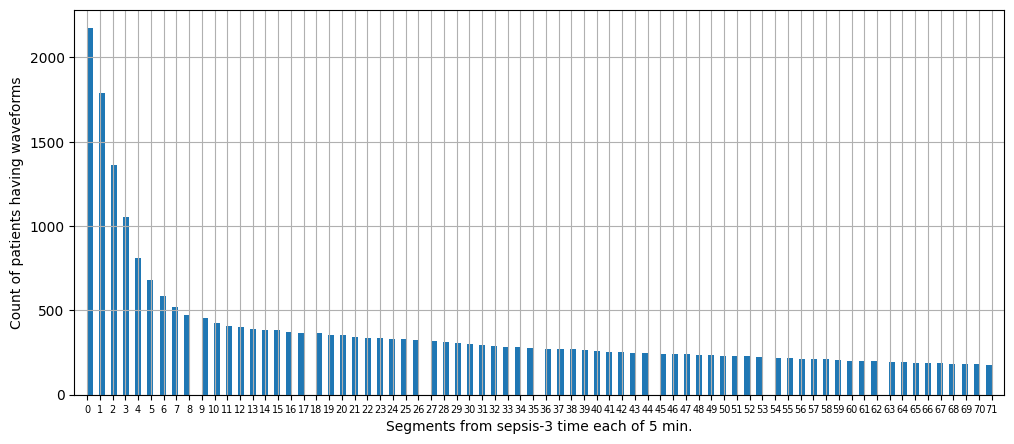

In [5]:
df_Sepsis_latest.segmentID.hist(bins=150, figsize=(12,5))
plt.xlabel('Segments from sepsis-3 time each of 5 min.')
plt.ylabel('Count of patients having waveforms')
plt.xlim([-1, 72])
plt.xticks(np.arange(72), size=7)
plt.show()

# Step 3: Map with target variables (Short term mortality, VPFD, VFD, ICU LOS)

In [6]:
df_Sepsis_latest.fin.nunique(), df_Sepsis_latest.studyID.nunique(), df_Sepsis_latest.shape

(2185, 2100, (26749, 1171))

In [7]:
df_Sepsis_latest['t_sepsis'] = pd.to_datetime(df_Sepsis_latest.t_sepsis)

In [8]:
# ==== Short term Septic shock Status ==== 

df_SShock = pd.read_csv('Data_folder/Event_Table/septicShock_encounters_final_Pitt.csv')
df_SShock['studyID'] = df_SShock.StudyID.astype('str')
df_SShock['fin'] = df_SShock.FIN.astype('int')
df_SShock.drop_duplicates(inplace=True)
df_SShock.reset_index(inplace=True, drop=True)

df_SShock['earliest_VP_On'] = pd.to_datetime(df_SShock['earliest_VP_On'])
df_SShock['earliest_lacticAcid>2'] = pd.to_datetime(df_SShock['earliest_lacticAcid>2'])
# Create SS_time as the maximum of the two
df_SShock['SS_time'] = df_SShock[['earliest_VP_On', 'earliest_lacticAcid>2']].max(axis=1)
df_SShock = df_SShock[['studyID','fin','SS_time']]
df_SShock['SS'] = True
df_SShock.shape

(33283, 4)

In [ ]:
### For SS Analysis Table

df_Sepsis_latest_SS = df_Sepsis_latest.merge(df_SShock, on=['fin'], how='left')
df_Sepsis_latest_SS['SS_time'] = pd.to_datetime(df_Sepsis_latest_SS.SS_time)
df_Sepsis_latest_SS[df_Sepsis_latest_SS.SS.isnull()] = False
print(df_Sepsis_latest_SS.SS.unique(), df_Sepsis_latest_SS.SS.isnull().sum(), df_Sepsis_latest_SS.shape)

### s_SS_Xd_final: Descriptive short-term SS table patient encounter wise.

s_SS = df_Sepsis_latest_SS[['fin','t_sepsis','SS_time','SS']].drop_duplicates()
s_SS.reset_index(drop=True, inplace=True)

def SS_X_days(df, Xdays=28):
    df['SS_time'] = pd.to_datetime(df['SS_time'], errors='coerce')
    df['t_sepsis'] = pd.to_datetime(df['t_sepsis'], errors='coerce')
    delT_sep_SS = (df['SS_time']-df['t_sepsis']).dt.days #SS day would be 100% after the sepsis3 time
    delT_sep_SS[delT_sep_SS>Xdays] = np.nan
    delT_sep_SS[df['SS']==False] = np.nan
    df['delT_sep_SS'] = delT_sep_SS
    s_SS_Xd = df[~df['delT_sep_SS'].isnull()]
    s_SS_Xd['day_postS3'] = s_SS_Xd['delT_sep_SS'].astype(int)
    s_SS_Xd[f'SS_{Xdays}'] = s_SS_Xd['SS'].astype(int)
    s_SS_Xd_final = s_SS_Xd[['fin','day_postS3',f'SS_{Xdays}']]
    s_SS_Xd_final.reset_index(drop=True, inplace=True)
    print(s_SS_Xd_final.head(), s_SS_Xd_final.shape, s_SS_Xd_final.fin.nunique())
    return s_SS_Xd_final

df = s_SS.copy()
s_SS_28d_final = SS_X_days(df, Xdays=28)
s_SS_7d_final = SS_X_days(df, Xdays=7)
s_SS_2d_final = SS_X_days(df, Xdays=2)
s_SS_1d_final = SS_X_days(df, Xdays=1)


s_SS_28_7d = s_SS_28d_final.merge(s_SS_7d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d = s_SS_28_7d.merge(s_SS_2d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d_1d = s_SS_28_7_2d.merge(s_SS_1d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d_1d.loc[:,'SS_7'][s_SS_28_7_2d_1d['SS_7'].isnull()] = 0
s_SS_28_7_2d_1d.loc[:,'SS_2'][s_SS_28_7_2d_1d['SS_2'].isnull()] = 0
s_SS_28_7_2d_1d.loc[:,'SS_1'][s_SS_28_7_2d_1d['SS_1'].isnull()] = 0
s_SS_28_7_2d_1d['SS_7'] = s_SS_28_7_2d_1d['SS_7'].astype(int)
s_SS_28_7_2d_1d['SS_2'] = s_SS_28_7_2d_1d['SS_2'].astype(int)
s_SS_28_7_2d_1d['SS_1'] = s_SS_28_7_2d_1d['SS_1'].astype(int)
s_SS_28_7_2d_1d = s_SS_28_7_2d_1d.drop_duplicates()
s_SS_28_7_2d_1d.reset_index(inplace=True, drop=True)
s_SS_28_7_2d_1d


In [9]:
# ==== Short term mortality =====


demo = pd.read_csv('Data_folder/Event_Table/tcdemographics_mladi24_new.csv')
demo['studyID'] = demo.study_id.astype('str')
demo['fin'] = demo.FIN_study_id.astype('int')
demo.drop_duplicates(inplace=True)
demo.reset_index(inplace=True, drop=True)
death = demo.disch_disp.str.contains('CTB|Expired', na=False) #'CTB' only
demo['death'] = death.values
demo.loc[:,'death'][demo.death.isnull()] = False

# # For Creating Demographics Table One 
# s_demographic = demo[demo.fin.isin(df_Sepsis_latest.fin)].drop_duplicates(subset='studyID',keep='first')
# s_demographic.reset_index(inplace=True, drop=True)
# s_demographic.columns, s_demographic.shape


In [ ]:
### For Mortality Analysis Table

df_Sepsis_latest_demo = df_Sepsis_latest.merge(demo, on=['fin'], how='left') #Just to carry demographic data as well
df_Sepsis_latest_demo['disch_date'] = pd.to_datetime(df_Sepsis_latest_demo.disch_date)
df_Sepsis_latest_demo.loc[:,'death'][df_Sepsis_latest_demo.death.isnull()] = False
print(df_Sepsis_latest_demo.death.unique(), df_Sepsis_latest_demo.death.isnull().sum(), df_Sepsis_latest_demo.shape)

### s_death_Xd_final: Descriptive short-term mortality/death table patient encounter wise.

s_death = df_Sepsis_latest_demo[['fin','t_sepsis','disch_date','death']].drop_duplicates()
s_death.reset_index(drop=True, inplace=True)

def STM_X_days(df, Xdays=28):
    delT_sep_death = (df['disch_date']-df['t_sepsis']).dt.days #Death day would be 100% after the sepsis3 time
    delT_sep_death[delT_sep_death>Xdays] = np.nan
    delT_sep_death[df['death']==False] = np.nan
    df['delT_sep_death'] = delT_sep_death
    s_death_Xd = df[~df['delT_sep_death'].isnull()]
    s_death_Xd['day_postS3'] = s_death_Xd['delT_sep_death'].astype(int)
    s_death_Xd[f'death_{Xdays}'] = s_death_Xd['death'].astype(int)
    s_death_Xd_final = s_death_Xd[['fin','day_postS3',f'death_{Xdays}']]
    s_death_Xd_final.reset_index(drop=True, inplace=True)
    print(s_death_Xd_final.head(), s_death_Xd_final.shape, s_death_Xd_final.fin.nunique())
    return s_death_Xd_final

df = s_death.copy()
s_death_28d_final = STM_X_days(df, Xdays=28)
s_death_7d_final = STM_X_days(df, Xdays=7)
s_death_2d_final = STM_X_days(df, Xdays=2)
s_death_1d_final = STM_X_days(df, Xdays=1)

s_death_28_7d = s_death_28d_final.merge(s_death_7d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d = s_death_28_7d.merge(s_death_2d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d_1d = s_death_28_7_2d.merge(s_death_1d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d_1d.loc[:,'death_7'][s_death_28_7_2d_1d['death_7'].isnull()] = 0
s_death_28_7_2d_1d.loc[:,'death_2'][s_death_28_7_2d_1d['death_2'].isnull()] = 0
s_death_28_7_2d_1d.loc[:,'death_1'][s_death_28_7_2d_1d['death_1'].isnull()] = 0
s_death_28_7_2d_1d['death_7'] = s_death_28_7_2d_1d['death_7'].astype(int)
s_death_28_7_2d_1d['death_2'] = s_death_28_7_2d_1d['death_2'].astype(int)
s_death_28_7_2d_1d['death_1'] = s_death_28_7_2d_1d['death_1'].astype(int)
s_death_28_7_2d_1d = s_death_28_7_2d_1d.drop_duplicates()
s_death_28_7_2d_1d.reset_index(inplace=True, drop=True)
s_death_28_7_2d_1d

In [ ]:

# ==== Vasopressor-free days (VPFD) ====

# The number of days a patient survives and remains without requiring the use of vasopressor medications.
# Procedure: VPFD are typically counted as the number of consecutive days a patient is alive and does not require vasopressor therapy.
# VPFD = 0, if patient died within 28 days window.
df_VP = pd.read_csv('Data_folder/Event_Table/sepsis_all_VP_Before28D.csv')
df_VP.drop(df_VP.columns[df_VP.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_VP['studyID'] = df_VP['studyID'].astype('str')
df_VP['fin'] = df_VP['fin'].astype('int')
df_VP['T_vp_postS3'] = pd.to_datetime(df_VP['T_vp_postS3'])
df_VP['t_sepsis'] = pd.to_datetime(df_VP['t_sepsis'])
print(df_VP.columns, df_VP.shape)


### For VPFD Analysis Table on patient encounter level
df_s = df_Sepsis_latest_demo[['fin','t_sepsis','segmentID']].drop_duplicates()
s_vp = df_s.merge(df_VP, on=['fin','t_sepsis'], how='left') #,'studyID','t_sepsis'
s_vp_seg0 = s_vp[s_vp['segmentID']==0]
s_vp_seg0.reset_index(inplace=True, drop=True)
print(s_vp_seg0.shape, s_vp_seg0.fin.nunique(), s_vp_seg0.studyID.nunique())


### s_vpfd_Xd_final: Descriptive VPFD table
def VPFD_X_days(df, Xdays=28):
    s_vpfd = df[['fin','t_sepsis','T_vp_postS3']].drop_duplicates()
    s_vpfd.reset_index(drop=True, inplace=True)
    s_vpfd['delT_sep_vp'] = (s_vpfd['T_vp_postS3']-s_vpfd['t_sepsis']).dt.days #T_vp_postS3 day may be before or after the sepsis3 time
    s_vpfd_Xd = s_vpfd[(s_vpfd['delT_sep_vp']>=0) & (s_vpfd['delT_sep_vp']<=Xdays)] #tracking 0 to Xdays days after S3
    # No need to check if expired before X days. If expired, VP would have not been given.
    s_vpfd_Xd['day_postS3'] = s_vpfd_Xd['delT_sep_vp'].astype(int)
    s_vpfd_Xd[f'vp_{Xdays}'] = 1
    s_vpfd_Xd_final = s_vpfd_Xd[['fin','day_postS3',f'vp_{Xdays}']]
    s_vpfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_vpfd_Xd_final.head(), s_vpfd_Xd_final.shape, s_vpfd_Xd_final.fin.nunique())
    return s_vpfd_Xd_final

df = s_vp_seg0.copy()
s_vpfd_28d_final = VPFD_X_days(df, Xdays=28)
s_vpfd_7d_final = VPFD_X_days(df, Xdays=7)
s_vpfd_2d_final = VPFD_X_days(df, Xdays=2)
# s_vpfd_1d_final = VPFD_X_days(df, Xdays=1)

s_vpfd_28_7d = s_vpfd_28d_final.merge(s_vpfd_7d_final, how='left', on=['fin','day_postS3'])
s_vpfd_28_7_2d = s_vpfd_28_7d.merge(s_vpfd_2d_final, how='left', on=['fin','day_postS3'])
s_vpfd_28_7_2d.loc[:,'vp_7'][s_vpfd_28_7_2d['vp_7'].isnull()] = 0
s_vpfd_28_7_2d.loc[:,'vp_2'][s_vpfd_28_7_2d['vp_2'].isnull()] = 0
s_vpfd_28_7_2d['vp_7'] = s_vpfd_28_7_2d['vp_7'].astype(int)
s_vpfd_28_7_2d['vp_2'] = s_vpfd_28_7_2d['vp_2'].astype(int)
s_vpfd_28_7_2d = s_vpfd_28_7_2d.drop_duplicates()
s_vpfd_28_7_2d.reset_index(inplace=True, drop=True)
s_vpfd_28_7_2d  #Received VP in next 28d, 7d, 2d, 1d after Sepsis3 onset

In [12]:
f_imv = pd.read_csv('../pitts_emr_data/vitals_IMVvent.csv')
f_imv.columns

Index(['study_id', 'FIN_study_id', 'chartdate', 'UTCOffset', 'event_name',
       'result_val', 'result_unit', 'vent_status'],
      dtype='object')

In [ ]:

# ==== Vent-free days (VFD) ====
# The number of days a patient survives and remains without requiring the use of IMV.

df_imv = pd.read_csv('../pitts_emr_data/vitals_IMVvent.csv')
df_imv.drop(df_imv.columns[df_imv.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_imv['studyID'] = df_imv.study_id.astype('str')
df_imv['fin'] = df_imv.FIN_study_id.astype('int')
df_imv['T_imv_postS3'] = pd.to_datetime(df_imv.chartdate)
print(df_imv.shape, df_imv.columns)

### For VFD Analysis Table on patient encounter level
df_imv = df_imv[['studyID','fin','T_imv_postS3']]
s_imv = df_Sepsis_latest_demo.merge(df_imv, on=['fin'], how='left')
s_imv_seg0 = s_imv[s_imv['segmentID']==0]
s_imv_seg0.reset_index(inplace=True, drop=True)
print(s_imv_seg0.shape, s_imv_seg0.fin.nunique(), s_imv_seg0.studyID.nunique())

### s_vfd_28d_final: Descriptive VFD table
def VFD_X_days(df, Xdays=28):
    s_vfd = df[['fin','t_sepsis','T_imv_postS3']].drop_duplicates()
    s_vfd.reset_index(drop=True, inplace=True)
    s_vfd['delT_sep_imv'] = (s_vfd['T_imv_postS3']-s_vfd['t_sepsis']).dt.days #T_imv_postS3 day may be before or after the sepsis3 time
    s_vfd_Xd = s_vfd[(s_vfd['delT_sep_imv']>=0) & (s_vfd['delT_sep_imv']<=Xdays)] #tracking 0 to X days after S3
    # No need to check if expired before X days. If expired, they would have not been ventilated.
    s_vfd_Xd['day_postS3'] = s_vfd_Xd['delT_sep_imv'].astype(int)
    s_vfd_Xd[f'vent_{Xdays}'] = 1
    s_vfd_Xd_final = s_vfd_Xd[['fin','day_postS3',f'vent_{Xdays}']]
    s_vfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_vfd_Xd_final.head(), s_vfd_Xd_final.shape)
    return s_vfd_Xd_final

df = s_imv_seg0.copy()
s_vfd_28d_final = VFD_X_days(df, Xdays=28)
s_vfd_7d_final = VFD_X_days(df, Xdays=7)
s_vfd_2d_final = VFD_X_days(df, Xdays=2)    

s_vfd_28_7d = s_vfd_28d_final.merge(s_vfd_7d_final, how='left', on=['fin','day_postS3'])
s_vfd_28_7_2d = s_vfd_28_7d.merge(s_vfd_2d_final, how='left', on=['fin','day_postS3'])
s_vfd_28_7_2d.loc[:,'vent_7'][s_vfd_28_7_2d['vent_7'].isnull()] = 0
s_vfd_28_7_2d.loc[:,'vent_2'][s_vfd_28_7_2d['vent_2'].isnull()] = 0
s_vfd_28_7_2d['vent_7'] = s_vfd_28_7_2d['vent_7'].astype(int)
s_vfd_28_7_2d['vent_2'] = s_vfd_28_7_2d['vent_2'].astype(int)
s_vfd_28_7_2d = s_vfd_28_7_2d.drop_duplicates()
s_vfd_28_7_2d.reset_index(inplace=True, drop=True)
s_vfd_28_7_2d #Received Vent support in next 28d, 7d, 2d, 1d after Sepsis3 onset

In [14]:
s_vfd_28_7d.shape

(74108, 4)

In [ ]:
# === Bolus free days =====
df_bolus = pd.read_csv('Data_folder/Event_Table/sepsis_all_bolus_Before28D.csv')
df_bolus.drop(df_bolus.columns[df_bolus.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_bolus['studyID'] = df_bolus.studyID.astype('str')
df_bolus['fin'] = df_bolus.fin.astype('int')
df_bolus['T_bolus_postS3'] = pd.to_datetime(df_bolus['T_bolus_postS3'])
df_bolus['t_sepsis'] = pd.to_datetime(df_bolus['t_sepsis'])
print(df_bolus.columns, df_bolus.shape)


### For BFD Analysis Table on patient encounter level

s_b = df_Sepsis_latest_demo.merge(df_bolus, on=['fin','t_sepsis'], how='left') #'studyID','t_sepsis'
s_b_seg0 = s_b[s_b['segmentID']==0]
s_b_seg0.reset_index(inplace=True, drop=True)
print(s_b_seg0.shape, s_b_seg0.fin.nunique(), s_b_seg0.studyID.nunique())


### s_bfd_28d_final: Descriptive VPFD table
def BFD_X_days(df, Xdays=28):
    s_bfd = df[['fin','t_sepsis','T_bolus_postS3']].drop_duplicates()
    s_bfd.reset_index(drop=True, inplace=True)
    s_bfd['delT_sep_b'] = (s_bfd['T_bolus_postS3']-s_bfd['t_sepsis']).dt.days #T_bolus_postS3 day may be before or after the sepsis3 time
    s_bfd_Xd = s_bfd[(s_bfd['delT_sep_b']>=0) & (s_bfd['delT_sep_b']<=Xdays)] #tracking 0 to X days after S3
    # No need to check if expired before X days. If expired, VP would have not been given.
    s_bfd_Xd['day_postS3'] = s_bfd_Xd['delT_sep_b'].astype(int)
    s_bfd_Xd[f'bolus_{Xdays}'] = 1
    s_bfd_Xd_final = s_bfd_Xd[['fin','day_postS3',f'bolus_{Xdays}']]
    s_bfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_bfd_Xd_final.head(), s_bfd_Xd_final.shape, s_bfd_Xd_final.fin.nunique())
    return s_bfd_Xd_final

df = s_b_seg0.copy()
s_bfd_28d_final = BFD_X_days(df, Xdays=28)
s_bfd_7d_final = BFD_X_days(df, Xdays=7)
s_bfd_2d_final = BFD_X_days(df, Xdays=2)  

s_bfd_28_7d = s_bfd_28d_final.merge(s_bfd_7d_final, how='left', on=['fin','day_postS3'])
s_bfd_28_7_2d = s_bfd_28_7d.merge(s_bfd_2d_final, how='left', on=['fin','day_postS3'])
s_bfd_28_7_2d.loc[:,'bolus_7'][s_bfd_28_7_2d['bolus_7'].isnull()] = 0
s_bfd_28_7_2d.loc[:,'bolus_2'][s_bfd_28_7_2d['bolus_2'].isnull()] = 0
s_bfd_28_7_2d['bolus_7'] = s_bfd_28_7_2d['bolus_7'].astype(int)
s_bfd_28_7_2d['bolus_2'] = s_bfd_28_7_2d['bolus_2'].astype(int)
s_bfd_28_7_2d = s_bfd_28_7_2d.drop_duplicates()
s_bfd_28_7_2d.reset_index(inplace=True, drop=True)
s_bfd_28_7_2d # Received boluses in next 28d, 7d, 2d, 1d after Sepsis3 onset



In [16]:
# ==== Vent status ====








In [17]:
# ==== ICU length of stay (LOS) ====








In [18]:
s_death_28d_final.columns, s_vpfd_28d_final.columns, s_vfd_28d_final.columns, s_bfd_28d_final.columns

(Index(['fin', 'day_postS3', 'death_28'], dtype='object'),
 Index(['fin', 'day_postS3', 'vp_28'], dtype='object'),
 Index(['fin', 'day_postS3', 'vent_28'], dtype='object'),
 Index(['fin', 'day_postS3', 'bolus_28'], dtype='object'))

In [19]:
s_SS_28_7_2d_1d.shape, s_death_28_7_2d_1d.shape, s_vpfd_28_7_2d.shape, s_vfd_28_7_2d.shape, s_bfd_28_7_2d.shape

((1269, 6), (451, 6), (5195, 5), (8014, 5), (1763, 5))

In [20]:
value_counts_per_column = {colms: s_death_28_7_2d_1d[colms].value_counts() for colms in s_death_28_7_2d_1d.columns[2:]}
value_counts_per_column

{'death_28': death_28
 1    451
 Name: count, dtype: int64,
 'death_7': death_7
 0    249
 1    202
 Name: count, dtype: int64,
 'death_2': death_2
 0    376
 1     75
 Name: count, dtype: int64,
 'death_1': death_1
 0    404
 1     47
 Name: count, dtype: int64}

In [ ]:
df_death_vp = s_death_28_7_2d_1d.merge(s_vpfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent = df_death_vp.merge(s_vfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd = df_death_vp_vent.merge(s_bfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd_SS = df_death_vp_vent_bfd.merge(s_SS_28_7_2d_1d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd_SS_final = df_death_vp_vent_bfd_SS.sort_values(by=['fin','day_postS3'])
df_death_vp_vent_bfd_SS_final.reset_index(inplace=True, drop=True)
df_death_vp_vent_bfd_SS_final

In [22]:
df_death_vp_vent_bfd_SS_final.fin.nunique(), df_death_vp_vent_bfd_SS_final.fin.unique()[:20]

(1669,
 array([1000018, 1000031, 1000056, 1000060, 1000063, 1000153, 1000195,
        1000230, 1000256, 1000258, 1000284, 1000285, 1000290, 1000292,
        1000312, 1000334, 1000369, 1000387, 1000399, 1000451], dtype=object))

In [ ]:
df_death_vp_vent_bfd_SS_final[df_death_vp_vent_bfd_SS_final.fin==1000256]

In [24]:
df_death_vp_vent_bfd_SS_final[df_death_vp_vent_bfd_SS_final.isnull()] = 0

In [25]:
for i in df_death_vp_vent_bfd_SS_final.columns:
    if i!='fin':
        df_death_vp_vent_bfd_SS_final[i] = df_death_vp_vent_bfd_SS_final[i].astype(int)

In [ ]:
df_death_vp_vent_bfd_SS_final

In [ ]:

''' ### ==== FINAL TARGET TABLE CREATION ==== '''

# # Example Data: Data for 3 patients over 5 days, including death info
# data = {
#     'fin': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3],
#     'day': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
#     'vasopressor': [1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0],  # 1 indicates vasopressor usage, 0 indicates no usage
#     'ventilator': [1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1],   # 1 indicates ventilator usage, 0 indicates no usage
#     'bolus': [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1],
#     'death': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]         # 1 indicates death, 0 indicates no death
# }
# df = pd.DataFrame(data)

df = df_death_vp_vent_bfd_SS_final.copy()

'''
# death = 1, if died within 28 day window

# vpfd = 28 - x, x: days on receiving VP
# vpfd = 0, if patient died within 28 day window

# bfd = 28 - x, x: days on receiving boluses
# bfd = 0, if patient died within 28 day window

# vfd = 28 - x, x: days on receiving vent
# vfd = 0, if patient died within 28 day window
# vfd = 0, if patient is not librated (final extubated) from vent (ignored this as extubation info is not found)
'''

def vasopressor_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    vp_column = f'vp_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        days_on_vp = patient_data[vp_column].sum()
        return max(0, max_days - days_on_vp)

def ventilator_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    vent_column = f'vent_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        vent_yes = (patient_data[vent_column] == 1).sum()
        return max(0, max_days - vent_yes)

def bolus_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    bolus_column = f'bolus_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        bolus_yes = (patient_data[bolus_column] == 1).sum()
        return max(0, max_days - bolus_yes)

# Check if a patient has died (at least once)
def death_status(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    return patient_data[death_column].max()  # 1 if the patient has died, 0 if not

# Check if a patient has SS
def SShock_status(patient_data, max_days=28):
    SS_column = f'SS_{max_days}'
    return patient_data[SS_column].max()  # 1 if the patient has died, 0 if not

# Check if a patient got VP
def vaso_need_status(patient_data, max_days=28):
    vp_column = f'vp_{max_days}'
    return patient_data[vp_column].max()  # 1 if the patient has died, 0 if not

# Check if a patient got Vent support
def vent_need_status(patient_data, max_days=28):
    vent_column = f'vent_{max_days}'
    return patient_data[vent_column].max()  # 1 if the patient has died, 0 if not

# Group by patient_id and apply the functions
vpfd_28 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=28)).reset_index(name='vp_free_days')
vpfd_7 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=7)).reset_index(name='vp_free_days')
vpfd_2 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=2)).reset_index(name='vp_free_days')

vfd_28 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=28)).reset_index(name='vent_free_days')
vfd_7 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=7)).reset_index(name='vent_free_days')
vfd_2 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=2)).reset_index(name='vent_free_days')

d_28 = df.groupby('fin').apply(lambda x: death_status(x, max_days=28)).reset_index(name='d_status')
d_7 = df.groupby('fin').apply(lambda x: death_status(x, max_days=7)).reset_index(name='d_status')
d_2 = df.groupby('fin').apply(lambda x: death_status(x, max_days=2)).reset_index(name='d_status')
d_1 = df.groupby('fin').apply(lambda x: death_status(x, max_days=1)).reset_index(name='d_status')

bfd_28 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=28)).reset_index(name='b_free_days')
bfd_7 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=7)).reset_index(name='b_free_days')
bfd_2 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=2)).reset_index(name='b_free_days')

ss_28 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=28)).reset_index(name='ss_status')
ss_7 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=7)).reset_index(name='ss_status')
ss_2 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=2)).reset_index(name='ss_status')
ss_1 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=1)).reset_index(name='ss_status')


vp_28 = df.groupby('fin').apply(lambda x: vaso_need_status(x, max_days=28)).reset_index(name='vp_need_status')
vp_7 = df.groupby('fin').apply(lambda x: vaso_need_status(x, max_days=7)).reset_index(name='vp_need_status')
vp_2 = df.groupby('fin').apply(lambda x: vaso_need_status(x, max_days=2)).reset_index(name='vp_need_status')
vp_1 = df.groupby('fin').apply(lambda x: vaso_need_status(x, max_days=1)).reset_index(name='vp_need_status')

v_28 = df.groupby('fin').apply(lambda x: vent_need_status(x, max_days=28)).reset_index(name='v_need_status')
v_7 = df.groupby('fin').apply(lambda x: vent_need_status(x, max_days=7)).reset_index(name='v_need_status')
v_2 = df.groupby('fin').apply(lambda x: vent_need_status(x, max_days=2)).reset_index(name='v_need_status')
v_1 = df.groupby('fin').apply(lambda x: vent_need_status(x, max_days=1)).reset_index(name='v_need_status')


# Combine both results into a new DataFrame
df_target = pd.DataFrame({
    'fin': vpfd_28.fin.values,
    'Death28': d_28.d_status.values, 'Death7': d_7.d_status.values, 'Death2': d_2.d_status.values,'Death1': d_1.d_status.values, 
    'vpfd28': vpfd_28.vp_free_days.values, 'vpfd7': vpfd_7.vp_free_days.values, 'vpfd2': vpfd_2.vp_free_days.values, 
    'vfd28': vfd_28.vent_free_days.values, 'vfd7': vfd_7.vent_free_days.values, 'vfd2': vfd_2.vent_free_days.values,
    'bfd28': bfd_28.b_free_days.values, 'bfd7': bfd_7.b_free_days.values, 'bfd2': bfd_2.b_free_days.values, 
    'ss28': ss_28.ss_status.values, 'ss7': ss_7.ss_status.values, 'ss2': ss_2.ss_status.values,'ss1': ss_1.ss_status.values, 
    'vp28': vp_28.vp_need_status.values, 'vp7': vp_7.vp_need_status.values, 'vp2': vp_2.vp_need_status.values, 'vp1': vp_1.vp_need_status.values,
    'v28': v_28.v_need_status.values, 'v7': v_7.v_need_status.values, 'v2': v_2.v_need_status.values, 'v1': v_1.v_need_status.values
})
df_target







In [28]:
df_target.fin.nunique()

1669

In [29]:
df_Sepsis_latest_wTarget = df_Sepsis_latest.merge(df_target, on='fin', how='left')

In [ ]:
df_Sepsis_latest_wTarget

In [31]:
df_Sepsis_latest_wTarget.loc[:,'Death28'][df_Sepsis_latest_wTarget['Death28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death7'][df_Sepsis_latest_wTarget['Death7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death2'][df_Sepsis_latest_wTarget['Death2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death1'][df_Sepsis_latest_wTarget['Death1'].isnull()] = 0
df_Sepsis_latest_wTarget['Death28'] = df_Sepsis_latest_wTarget['Death28'].astype(int)
df_Sepsis_latest_wTarget['Death7'] = df_Sepsis_latest_wTarget['Death7'].astype(int)
df_Sepsis_latest_wTarget['Death2'] = df_Sepsis_latest_wTarget['Death2'].astype(int)
df_Sepsis_latest_wTarget['Death1'] = df_Sepsis_latest_wTarget['Death1'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'vpfd28'][df_Sepsis_latest_wTarget['vpfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vpfd7'][df_Sepsis_latest_wTarget['vpfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vpfd2'][df_Sepsis_latest_wTarget['vpfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['vpfd28'] = df_Sepsis_latest_wTarget['vpfd28'].astype(int)
df_Sepsis_latest_wTarget['vpfd7'] = df_Sepsis_latest_wTarget['vpfd7'].astype(int)
df_Sepsis_latest_wTarget['vpfd2'] = df_Sepsis_latest_wTarget['vpfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'vfd28'][df_Sepsis_latest_wTarget['vfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vfd7'][df_Sepsis_latest_wTarget['vfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vfd2'][df_Sepsis_latest_wTarget['vfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['vfd28'] = df_Sepsis_latest_wTarget['vfd28'].astype(int)
df_Sepsis_latest_wTarget['vfd7'] = df_Sepsis_latest_wTarget['vfd7'].astype(int)
df_Sepsis_latest_wTarget['vfd2'] = df_Sepsis_latest_wTarget['vfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'bfd28'][df_Sepsis_latest_wTarget['bfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'bfd7'][df_Sepsis_latest_wTarget['bfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'bfd2'][df_Sepsis_latest_wTarget['bfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['bfd28'] = df_Sepsis_latest_wTarget['bfd28'].astype(int)
df_Sepsis_latest_wTarget['bfd7'] = df_Sepsis_latest_wTarget['bfd7'].astype(int)
df_Sepsis_latest_wTarget['bfd2'] = df_Sepsis_latest_wTarget['bfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'ss28'][df_Sepsis_latest_wTarget['ss28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss7'][df_Sepsis_latest_wTarget['ss7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss2'][df_Sepsis_latest_wTarget['ss2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss1'][df_Sepsis_latest_wTarget['ss1'].isnull()] = 0
df_Sepsis_latest_wTarget['ss28'] = df_Sepsis_latest_wTarget['ss28'].astype(int)
df_Sepsis_latest_wTarget['ss7'] = df_Sepsis_latest_wTarget['ss7'].astype(int)
df_Sepsis_latest_wTarget['ss2'] = df_Sepsis_latest_wTarget['ss2'].astype(int)
df_Sepsis_latest_wTarget['ss1'] = df_Sepsis_latest_wTarget['ss1'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'vp28'][df_Sepsis_latest_wTarget['vp28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vp7'][df_Sepsis_latest_wTarget['vp7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vp2'][df_Sepsis_latest_wTarget['vp2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vp1'][df_Sepsis_latest_wTarget['vp1'].isnull()] = 0
df_Sepsis_latest_wTarget['vp28'] = df_Sepsis_latest_wTarget['vp28'].astype(int)
df_Sepsis_latest_wTarget['vp7'] = df_Sepsis_latest_wTarget['vp7'].astype(int)
df_Sepsis_latest_wTarget['vp2'] = df_Sepsis_latest_wTarget['vp2'].astype(int)
df_Sepsis_latest_wTarget['vp1'] = df_Sepsis_latest_wTarget['vp1'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'v28'][df_Sepsis_latest_wTarget['v28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'v7'][df_Sepsis_latest_wTarget['v7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'v2'][df_Sepsis_latest_wTarget['v2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'v1'][df_Sepsis_latest_wTarget['v1'].isnull()] = 0
df_Sepsis_latest_wTarget['v28'] = df_Sepsis_latest_wTarget['v28'].astype(int)
df_Sepsis_latest_wTarget['v7'] = df_Sepsis_latest_wTarget['v7'].astype(int)
df_Sepsis_latest_wTarget['v2'] = df_Sepsis_latest_wTarget['v2'].astype(int)
df_Sepsis_latest_wTarget['v1'] = df_Sepsis_latest_wTarget['v1'].astype(int)


In [ ]:
df_Sepsis_latest_wTarget

In [35]:
df_Sepsis_latest_wTarget.columns[-16:]

Index(['Death7', 'Death2', 'Death1', 'vpfd28', 'vpfd7', 'vpfd2', 'vfd28',
       'vfd7', 'vfd2', 'bfd28', 'bfd7', 'bfd2', 'ss28', 'ss7', 'ss2', 'ss1'],
      dtype='object')

# Saving df_Sepsis_latest with Target variables

In [2]:
# df_Sepsis_latest_wTarget.to_csv('Data_folder/df_step2_TS_pitts_s3_MEDIANimp_physiomarkers_2016-2022_wTargets_v7.csv')












df_Sepsis_latest_wTarget = pd.read_csv('Data_folder/df_step2_TS_pitts_s3_MEDIANimp_physiomarkers_2016-2022_wTargets_v7.csv')

In [3]:
mapping_df = pd.read_csv('mapping.csv')
mapping_df.head()

,fid,Feature
0,ECG_T_rr_ms_mean,T_rr_ms_mean
1,ECG_T_rr_ms_median,T_rr_ms_median
2,ECG_T_rr_ms_std,T_rr_ms_std
3,ECG_T_rr_ms_mad,T_rr_ms_mad
4,ECG_T_rr_ms_iqr,T_rr_ms_iqr


In [4]:
feature_to_fid = dict(zip(mapping_df['Feature'], mapping_df['fid']))

# Rename df_B's columns using this mapping
df_Sepsis_latest_wTarget = df_Sepsis_latest_wTarget.rename(columns=feature_to_fid)

In [ ]:
df_presepsis_5min = df_Sepsis_latest_wTarget[df_Sepsis_latest_wTarget.segmentID==0]
df_presepsis_5min.reset_index(inplace=True, drop=True)
df_presepsis_5min

# Step 4: Build a phenotype predictor model with 1st 5min segment data prior to sepsis-3 time

In [7]:
# droplist = ['SBP', 'DBP', 'HR_ABP', 'MAP', 'PP_ABP', 'CO', 'TPR', 'ShockIndex']

In [6]:
df_Sepsis_latest_wTarget.columns[-28:]

Index(['RESP_resp_rate_Bpm_skewness', 'RESP_resp_rate_Bpm_kurtosis',
       'RESP_resp_rate_Bpm_entropy', 'RESP_resp_rate_Bpm_slope',
       'RESP_resp_rate_Bpm_autocorr_lag1', 'RESP_resp_rate_Bpm_gini_index',
       'RESP_resp_rate_Bpm_valid_n', 'qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs',
       'qSOFA_total', 'Death28', 'Death7', 'Death2', 'Death1', 'vpfd28',
       'vpfd7', 'vpfd2', 'vfd28', 'vfd7', 'vfd2', 'bfd28', 'bfd7', 'bfd2',
       'ss28', 'ss7', 'ss2', 'ss1'],
      dtype='object')

In [7]:
df_Sepsis_latest_wTarget.loc[:,'ECG_T_rr_ms_mean':'qSOFA_total'].shape #.drop(droplist, axis=1)

(26749, 1159)

In [8]:
'PPG_pat_ms_mean' in df_Sepsis_latest_wTarget.columns

True

In [9]:
feature_cols = list(df_Sepsis_latest_wTarget.loc[:,'ECG_T_rr_ms_mean':'qSOFA_total'].columns)
# remove_list = ['pat_ms', 'dpat_ms']
# feature_cols = list(filter(lambda x: x not in remove_list, feature_cols))

# feature_cols = [f for f in feature_cols if 'valid_n' not in f]
feature_cols = [f for f in feature_cols if 'valid_n' not in f and 'MSE_' not in f] # and 'qSOFA' not in f]

len(feature_cols)











1076

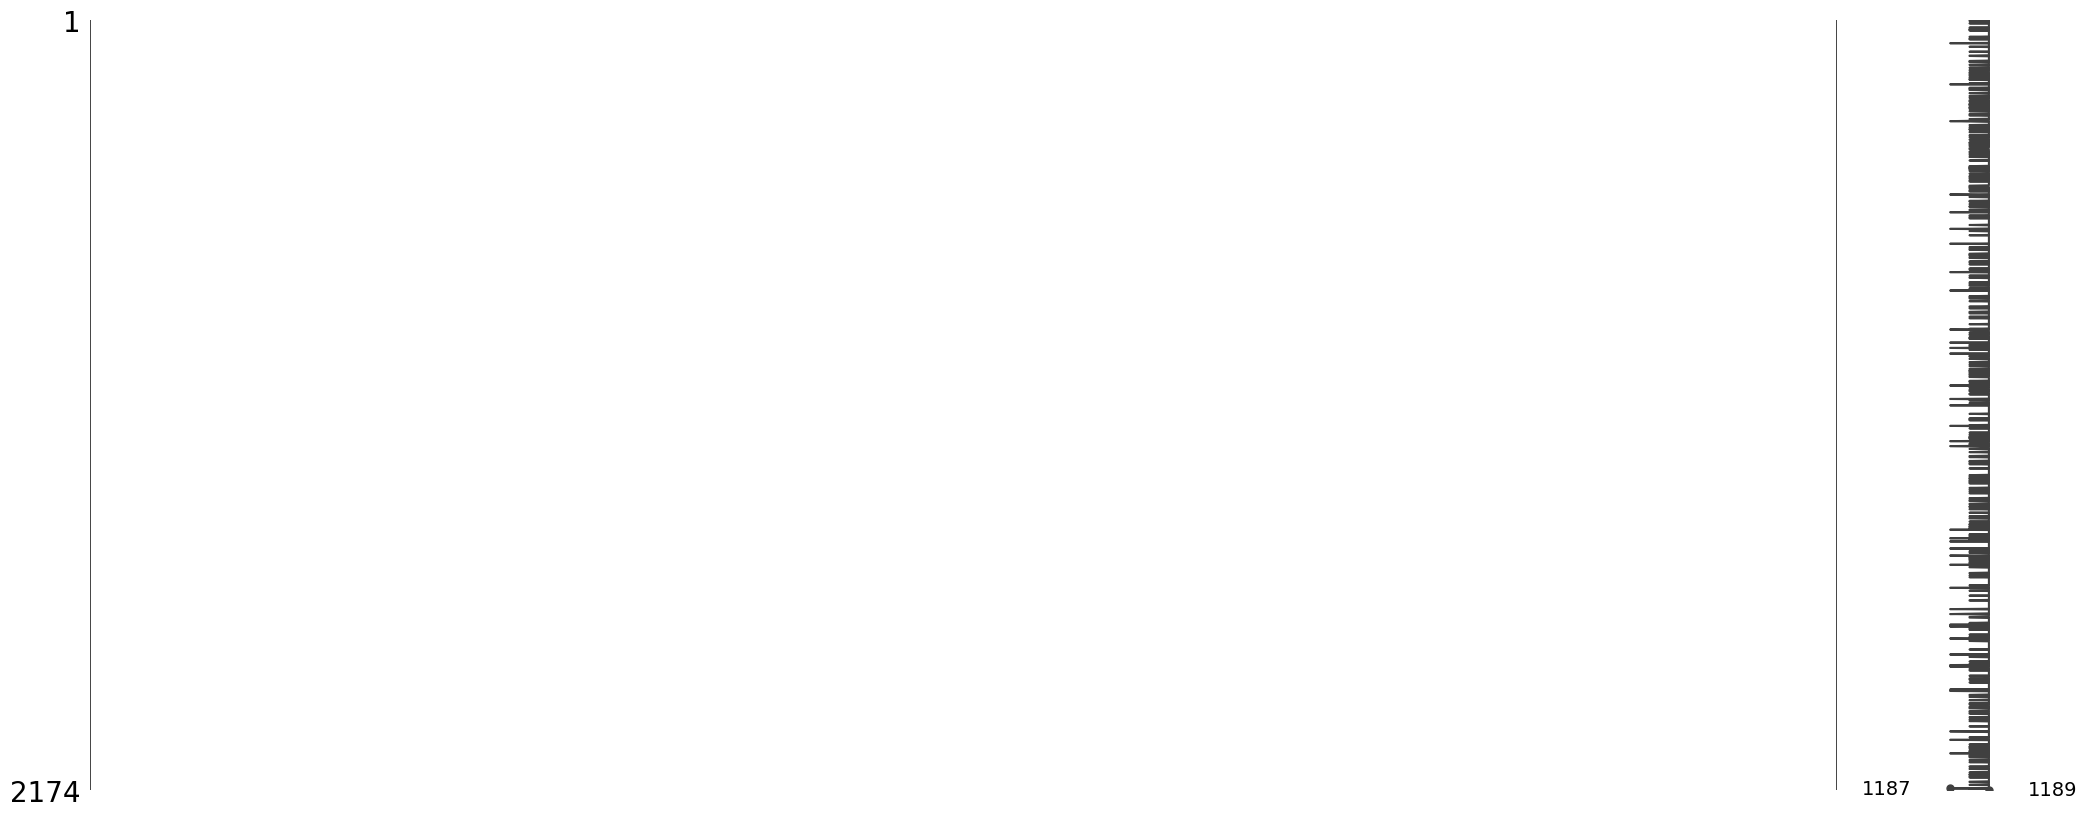

In [12]:
import missingno as msno
msno.matrix(df_presepsis_5min)
plt.show()

### features = ['mean', 'p25', 'p75', 'skewness', 'entropy']
This gives - center + spread + shape + uniformity — good coverage without major redundancy.

In [10]:
stats = ['_mad', '_iqr', '_median', '_min', '_max', '_std',
            '_kurtosis', '_slope', '_autocorr_lag1','_gini_index']


feature_cols = [f for f in feature_cols if not any(f.endswith(s) for s in stats)]

len(feature_cols)


429

In [11]:
feature_cols[:16]

['ECG_T_rr_ms_mean',
 'ECG_T_rr_ms_p25',
 'ECG_T_rr_ms_p75',
 'ECG_T_rr_ms_skewness',
 'ECG_T_rr_ms_entropy',
 'ECG_HR_bpm_mean',
 'ECG_HR_bpm_p25',
 'ECG_HR_bpm_p75',
 'ECG_HR_bpm_skewness',
 'ECG_HR_bpm_entropy',
 'ECG_edr_rate_Bpm_mean',
 'ECG_edr_rate_Bpm_p25',
 'ECG_edr_rate_Bpm_p75',
 'ECG_edr_rate_Bpm_skewness',
 'ECG_edr_rate_Bpm_entropy',
 'ECG_atrialSys_phase_mean']

In [13]:
# !pip install umap-learn

In [14]:
# conda install tensorflow

In [15]:
# !pip install tensorflow==2.13

In [16]:
# pip install umap-learn==0.5.5 scikit-learn==1.3.2

In [17]:
# import tc_tabular_consensus_clustering_pipeline_v4 as TCC
# '''Building phenotype predictor'''
# '''
# # dim_reduce_method: Dimensionality reduction method (default:None - no dim reduction): 'pca', 'umap', 'custom_embedding'
# # embedding_type: name of the method created embedding. (dafault: None): 'None', 'rbm'
# '''
# xgbmodel, metrics, cluster_labels, feature_list = TCC.clustering_and_prediction(df_presepsis_5min, 
#                                                                                 feature_cols, 
#                                                                                 standard_minmax='standard', var_thresh=0.04, corr_thresh=0.9, 
#                                                                                 verbose=1, 
#                                                                                 dim_reduce_method='custom_embedding', 
#                                                                                 embedding_type='vae_umap',
#                                                                                 k_opt=4
#                                                                                )

In [12]:
# 1. Import all required modules
# from tc_tabular_consensus_clustering_pipeline_v4 import clustering_and_prediction
# from TCC import clustering_and_prediction
# from integrated_sepsis_pipeline import IntegratedSepsisAnalysisPipeline, run_full_sepsis_analysis_with_llm
from sepsis_analysis_utils import run_complete_sepsis_analysis_workflow, load_analysis_results

# 2. Set up your API key (OpenAI or Claude)
API_PROVIDER = 'openai'
API_KEY = 'sk-..........' 
MODEL_NAME = 'gpt-4o'


2025-11-24 22:41:40.629009: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 22:41:40.629252: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 22:41:40.654128: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-24 22:41:42.410900: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

🚀 Starting Complete Sepsis Analysis Workflow
🚀 Starting Integrated Sepsis Phenotyping Analysis

📊 Step 1: Performing Consensus Clustering...
run_complete_analysis - var_thresh: 0.04, corr_thresh: 0.85, dim_reduce_method: custom_embedding, embedding_type: vae_umap
Custom Embedding
Epoch 1/200


2025-11-24 22:42:12.035362: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 27.4299 - val_loss: 9.1085 - learning_rate: 0.0010
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.1214 - val_loss: 6.0527 - learning_rate: 0.0010
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3352 - val_loss: 3.8363 - learning_rate: 0.0010
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6478 - val_loss: 2.7212 - learning_rate: 0.0010
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7327 - val_loss: 2.1358 - learning_rate: 0.0010
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.1616 - val_loss: 1.8099 - learning_rate: 0.0010
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7611 - val_loss: 1.5911 - learning_rate: 0.0010
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4568 - val_loss: 1.4588 - learning_rate: 0.0010
Epoch 9/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2142 - val_loss: 1.3509 - learning_rate: 0.0010
Epoch 10/200
62/62 ━━━━━━━━━━

Computing consensus matrices: 100%|██████████| 8/8 [00:00<00:00, 65281.00it/s]


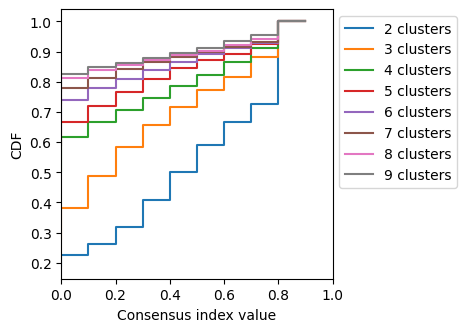

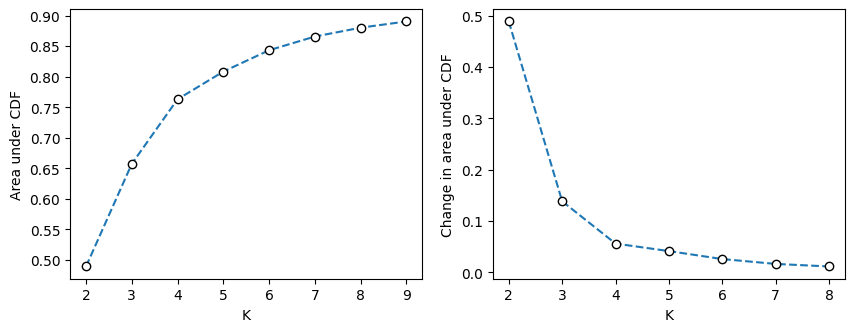

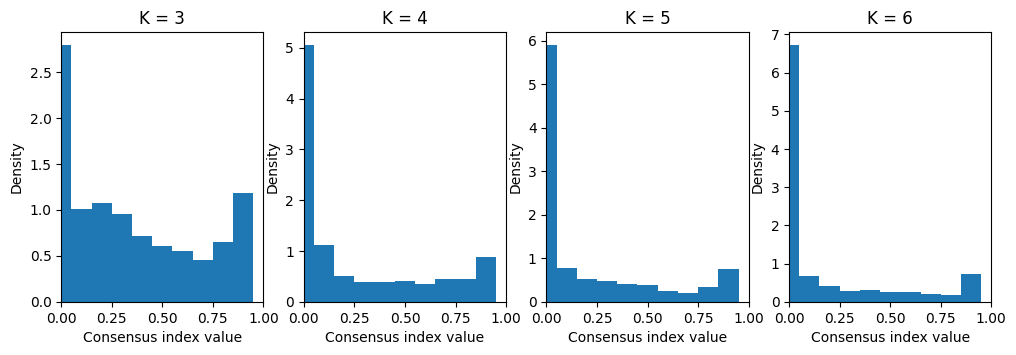

Best k from change in AUC: 2, and from AUC knee point: 4
Initial feature.shape: (2174, 429)
After VIF and dropping highly correlated features, feature.shape: (2174, 272)


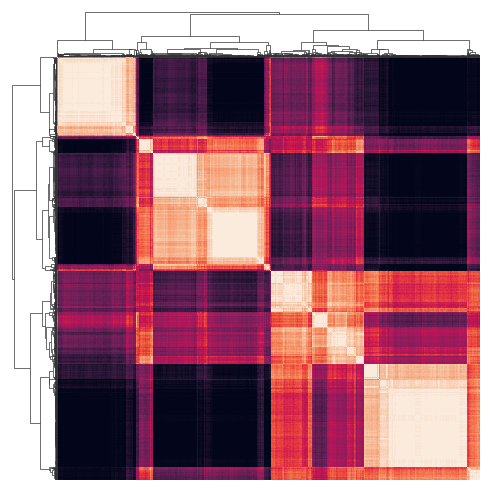

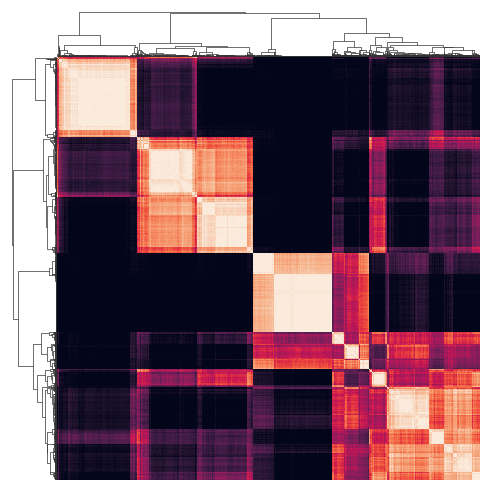

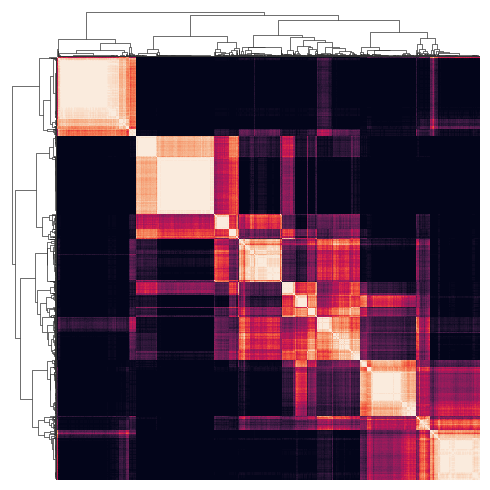

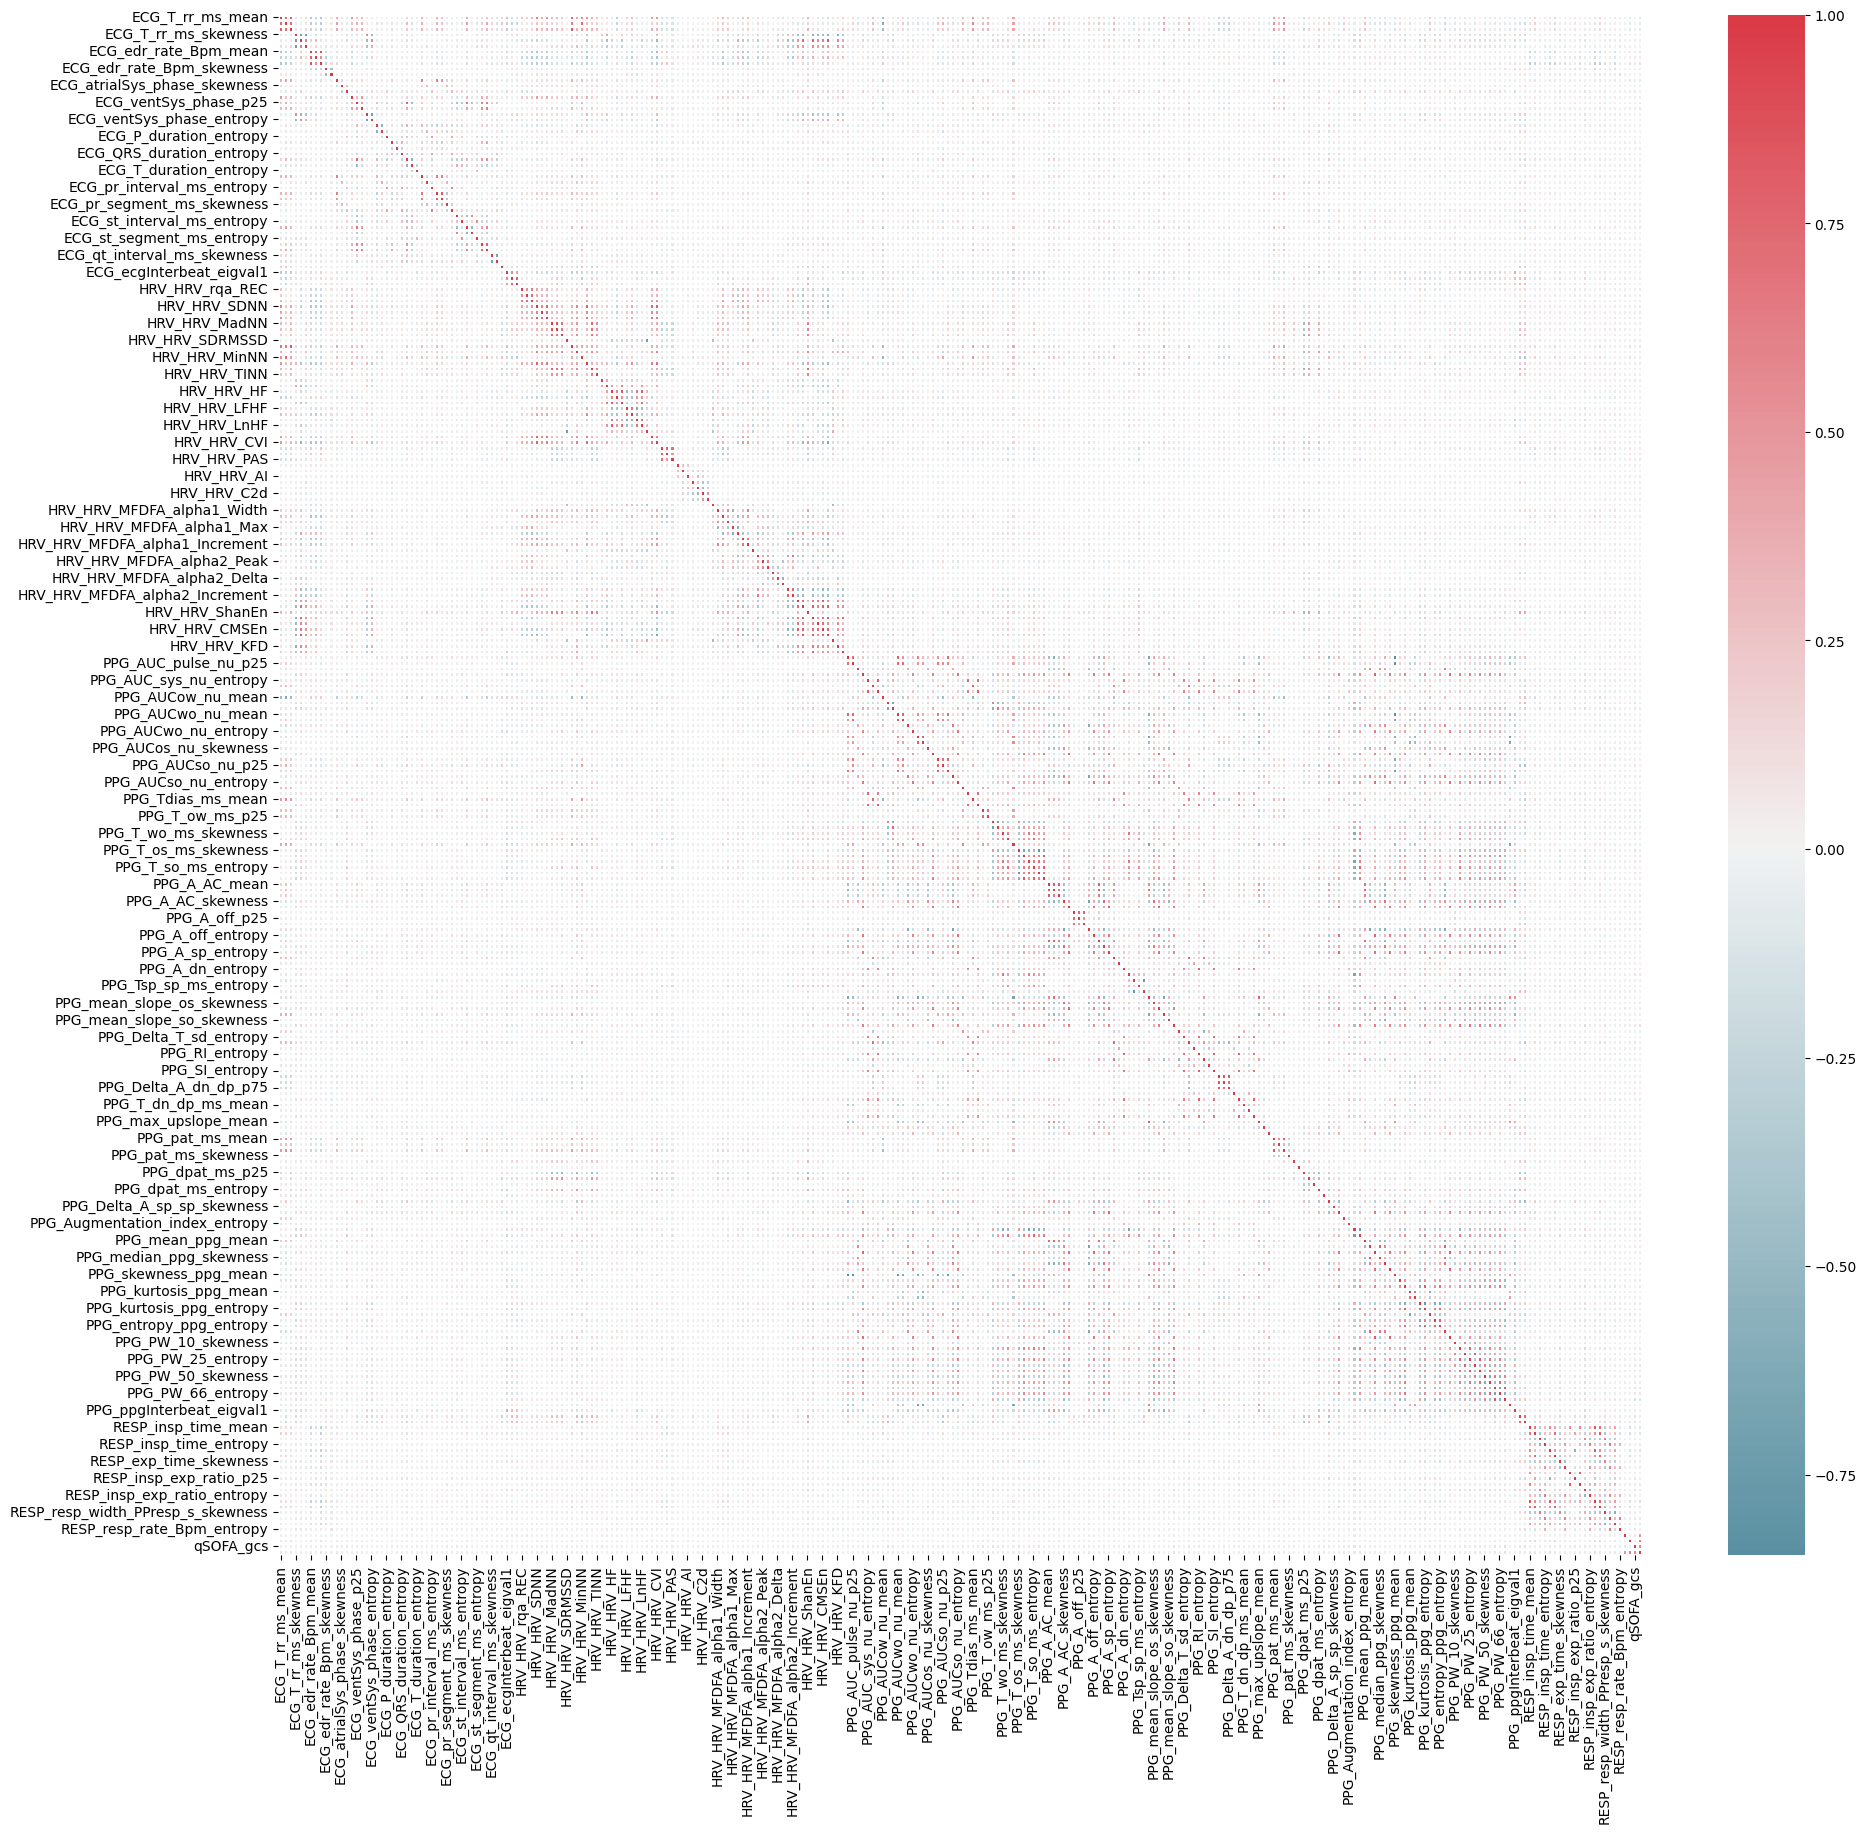

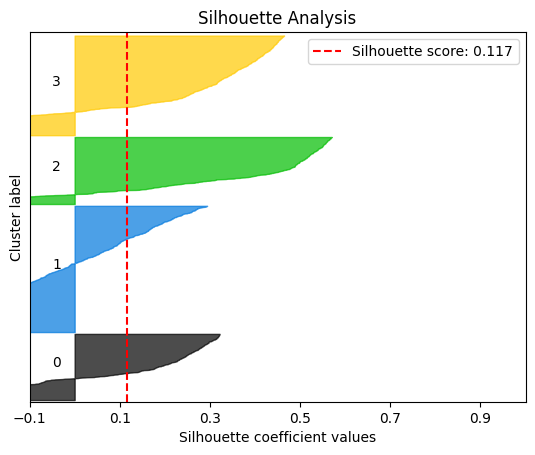

SS, DB, CH: 0.117, 2.081, 524.076
1    764
3    603
2    406
0    401
Name: count, dtype: int64


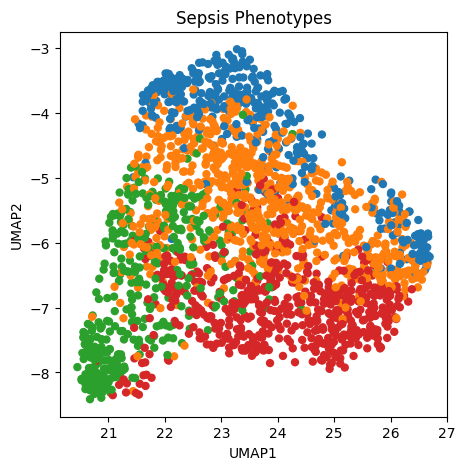

Shape of shap_values: (2174, 272, 4)
Shape of mean_abs_shap: (272,)
Length of sel_feature_list: 272
Number of features input to the model: 272
Train-test split: 1739 train, 435 test
Confusion matrix:
[[ 64  19   0   0]
 [  9 126   5   5]
 [  0  12  80   2]
 [  0   5   3 105]]
Overall accuracy: 0.862
Precision: [0.877 0.778 0.909 0.938]
Recall: [0.771 0.869 0.851 0.929]
F1-score: [0.821 0.821 0.879 0.933]
Accuracy per class: [0.771 0.869 0.851 0.929]
Predicted clusters on test set: Counter({1: 145, 3: 113, 2: 94, 0: 83})
selected feature list after filtering: 272

Top 5 features (overall):
                            feature  importance
59                    HRV_HRV_pNN50    0.389276
215  PPG_center_freq_ppg_Hz_entropy    0.279976
241               PPG_PW_50_entropy    0.262863
224        PPG_skewness_ppg_entropy    0.211201
237               PPG_PW_25_entropy    0.204222

Top 5 features per class:
Class 0:
                        feature  importance
241           PPG_PW_50_entropy    0

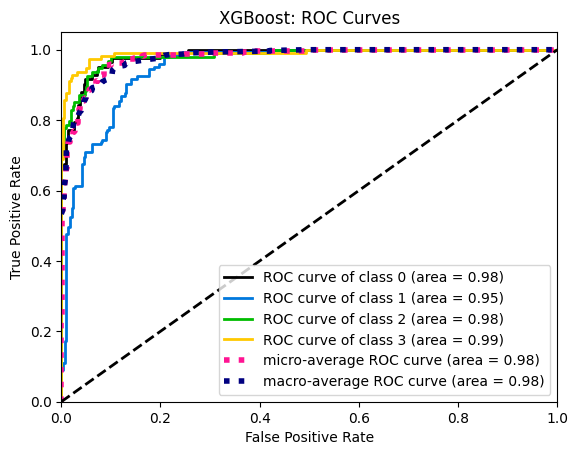

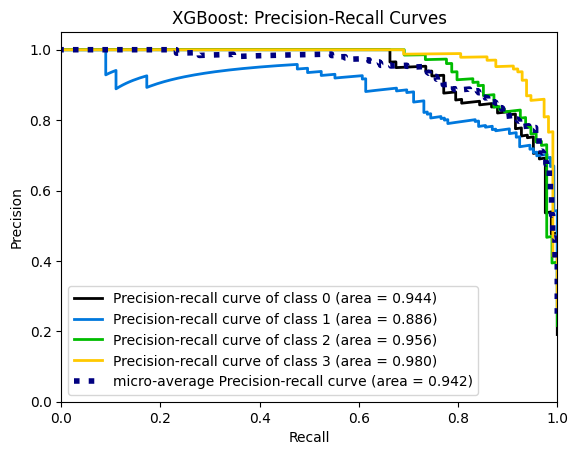

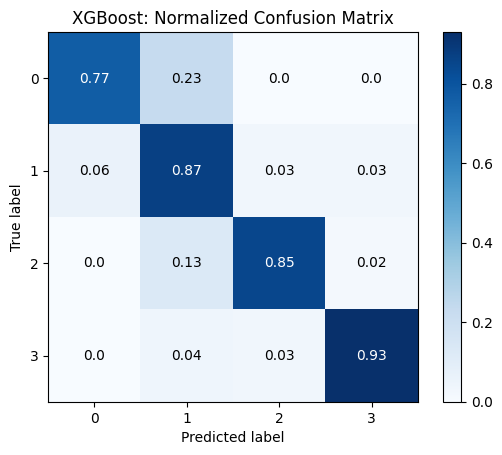

SHAP summary plot for phenotype 0


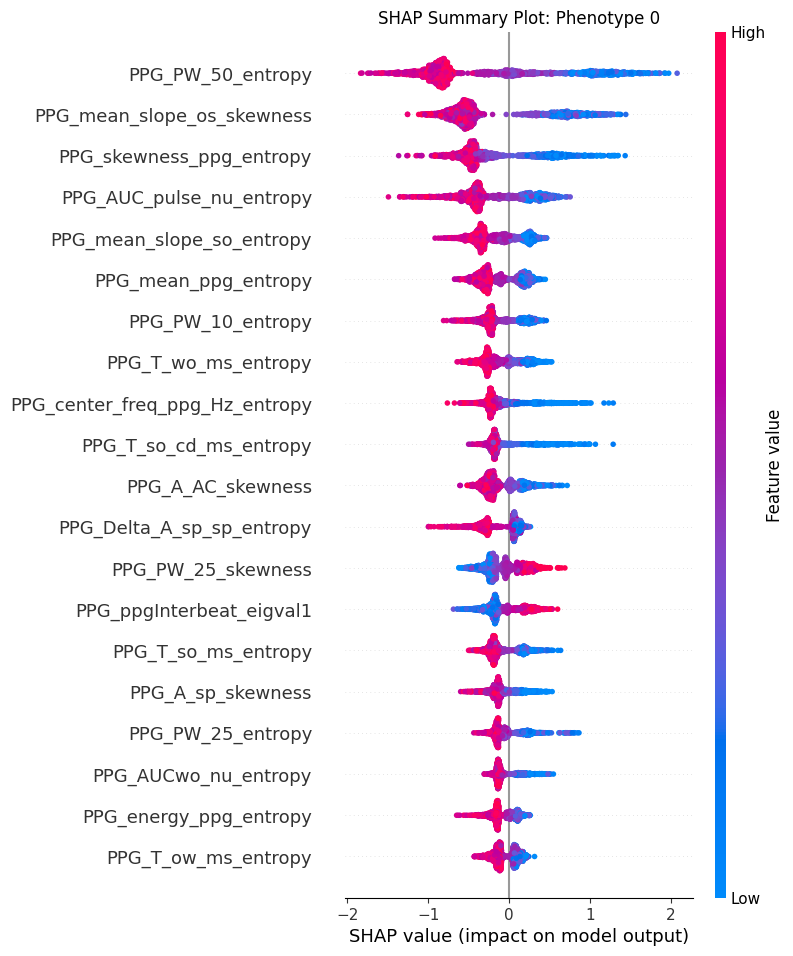

SHAP summary plot for phenotype 1


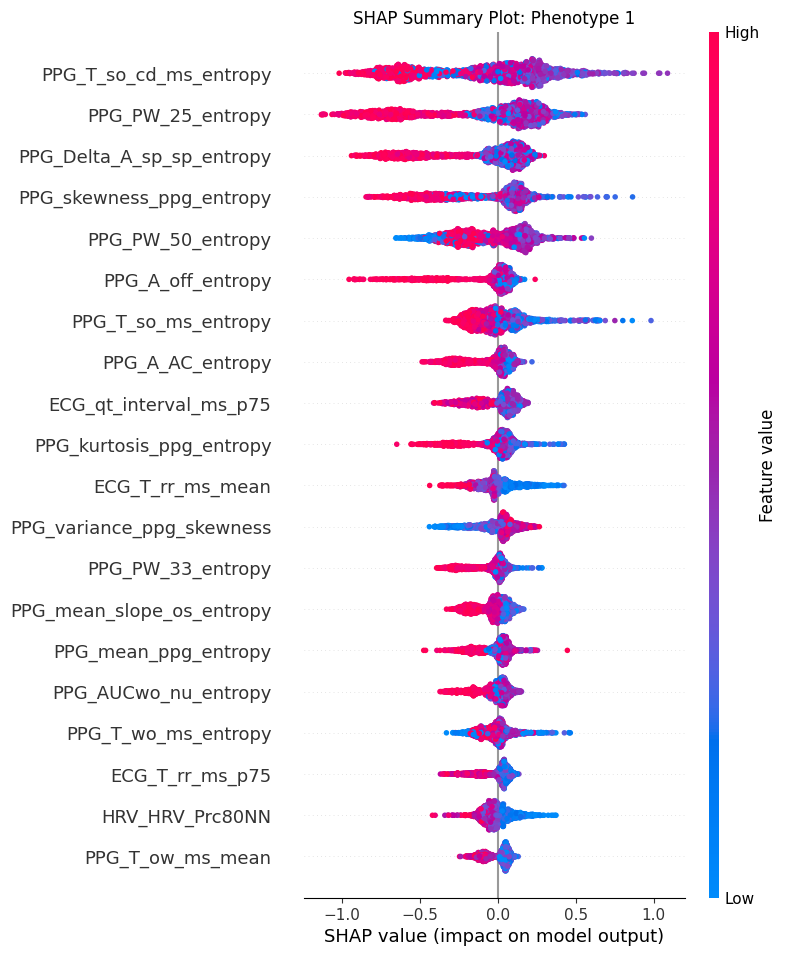

SHAP summary plot for phenotype 2


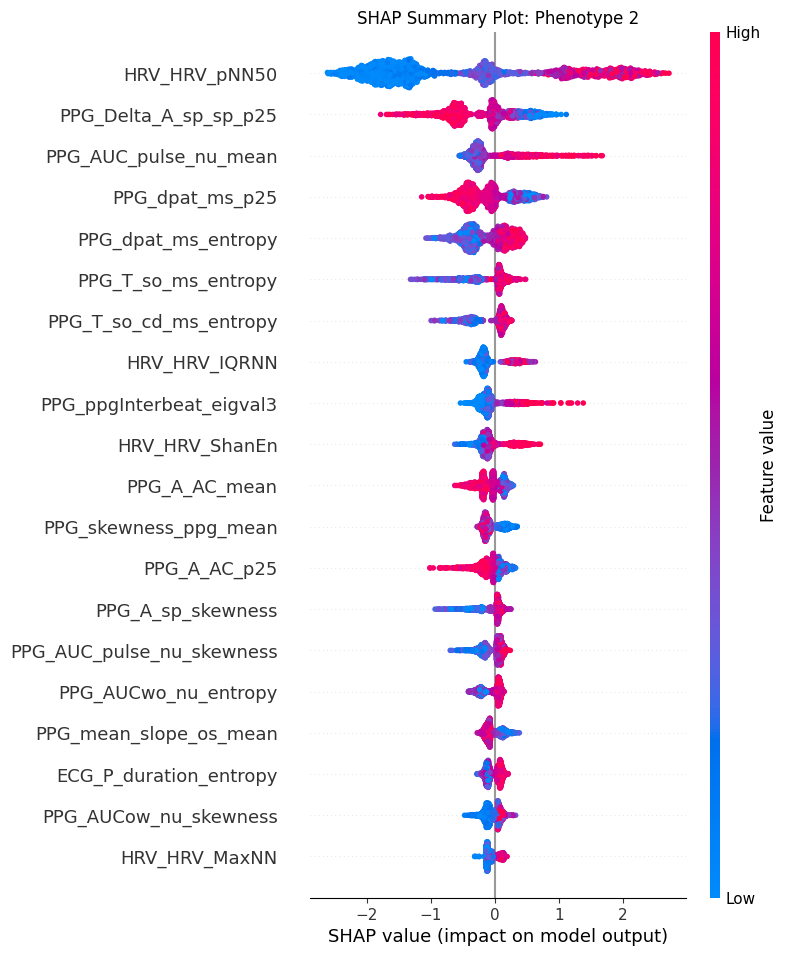

SHAP summary plot for phenotype 3


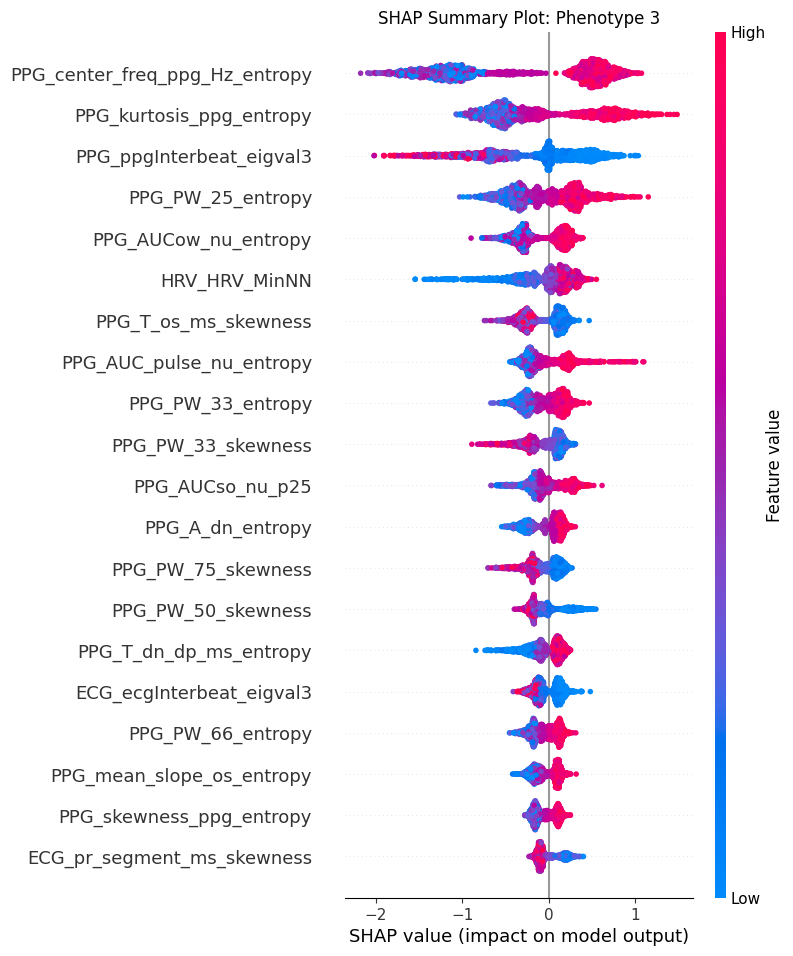

🔍 SHAP Values Debug Info:
Type: <class 'numpy.ndarray'>
Shape: (2174, 272, 4)
Number of dimensions: 3
Feature indices: 272 features
Sample feature indices: [('ECG_T_rr_ms_mean', 0), ('ECG_T_rr_ms_p25', 1), ('ECG_T_rr_ms_p75', 2), ('ECG_T_rr_ms_skewness', 3), ('ECG_T_rr_ms_entropy', 4)]
✅ Clustering complete: 4 phenotypes identified
   - 2174 patients analyzed
   - 272 features selected
   - Top SHAP features with mean absolute values per class: {0:                       feature  importance
0           PPG_PW_50_entropy    0.821402
1  PPG_mean_slope_os_skewness    0.621722
2    PPG_skewness_ppg_entropy    0.480605
3    PPG_AUC_pulse_nu_entropy    0.400938
4   PPG_mean_slope_so_entropy    0.283868, 1:                      feature  importance
0     PPG_T_so_cd_ms_entropy    0.330403
1          PPG_PW_25_entropy    0.329501
2  PPG_Delta_A_sp_sp_entropy    0.238719
3   PPG_skewness_ppg_entropy    0.235440
4          PPG_PW_50_entropy    0.191926, 2:                  feature  importance
0   

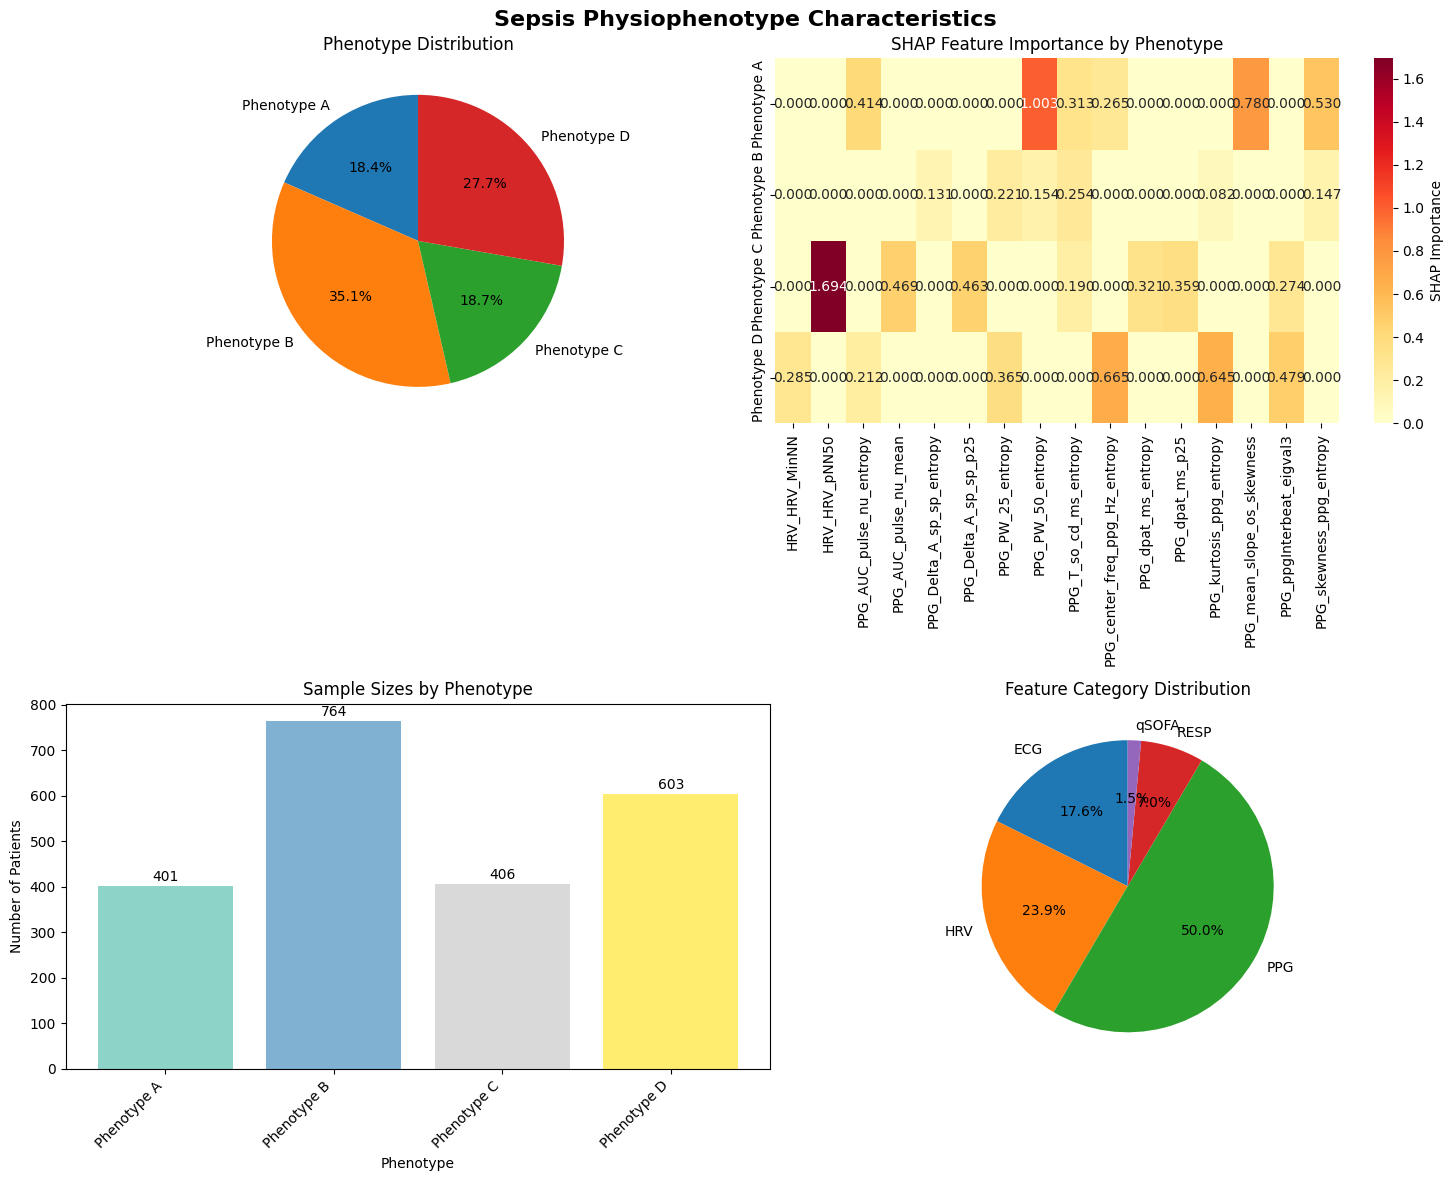

Results exported to: ./sepsis_phenotype_study_results/VAE_umap_latest/analysis_results/

SEPSIS PHENOTYPE ANALYSIS COMPLETE

Identified Sepsis Physiophenotypes:
• Cluster 0: Reduced Pulse Dynamics with Peripheral Hypoperfusion (401 patients, 18.4%)
• Cluster 1: Reduced Pulse Entropy with Cardiac Electrical Instability (764 patients, 35.1%)
• Cluster 2: Enhanced Parasympathetic Tone with Variable Perfusion (406 patients, 18.7%)
• Cluster 3: Enhanced PPG Entropy with Reduced Interbeat Variability (603 patients, 27.7%)

All results saved to: ./sepsis_phenotype_study_results/VAE_umap_latest/analysis_results/
✅ LLM interpretation complete
   - Phenotype names generated
   - Clinical interpretations created

📋 Step 3: Creating Analysis Summary...

💾 Step 4: Saving Results to ./sepsis_phenotype_study_results/VAE_umap_latest/analysis_results/
   ✅ Analysis summary: analysis_summary.json
   ✅ Cluster assignments: cluster_assignments.csv
   ✅ Selected features: selected_features.csv
   ✅ Trained

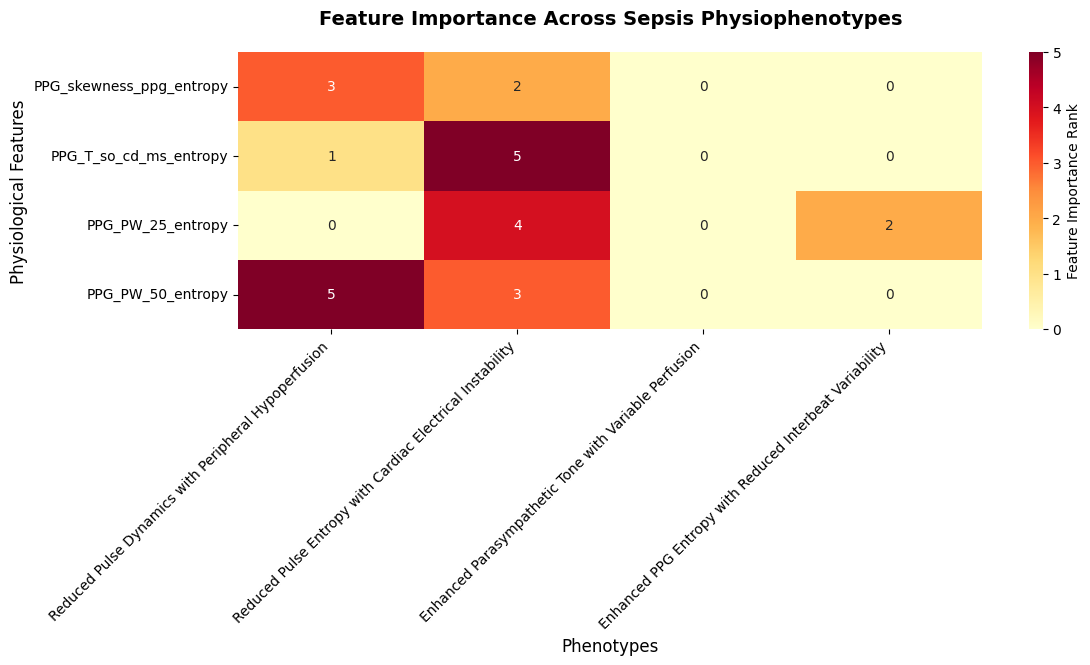

In [13]:
# 3. Run the complete workflow
results, validation_report, comparison_table, summary_cards = run_complete_sepsis_analysis_workflow(
    df_data=df_presepsis_5min,  # 2074 patients × 400+ features
    feature_columns=feature_cols,  # Your physiological features
    standard_minmax = 'standard',
    var_thresh = 0.04,
    corr_thresh = 0.85,
    dim_reduce_method = 'custom_embedding', 
    embedding_type = 'vae_umap',
    k_opt = 4,
    verbose = 1, 
    api_provider = API_PROVIDER,
    api_key = API_KEY,
    model_name = MODEL_NAME,
    clinical_outcomes=None,  # Optional: mortality, LOS, etc. outcomes_data
    output_base_dir="./sepsis_phenotype_study_results/VAE_umap_latest"
)

# 4. Access the generated phenotype names
phenotype_names = results['phenotype_names']
print("Generated Sepsis Phenotype Names:")
for cluster_id, name in phenotype_names.items():
    print(f"  Cluster {cluster_id}: {name}")
    
    
import pickle
output_base_dir="./sepsis_phenotype_study_results/VAE_umap_latest"
with open(f"{output_base_dir}/results.pkl", "wb") as f:
    pickle.dump(results, f)
    
    
# with open(f"{output_base_dir}\results.pkl", "rb") as f:
#     results = pickle.load(f)

len(epochs),len(train_loss),len(val_loss):  104 104 104


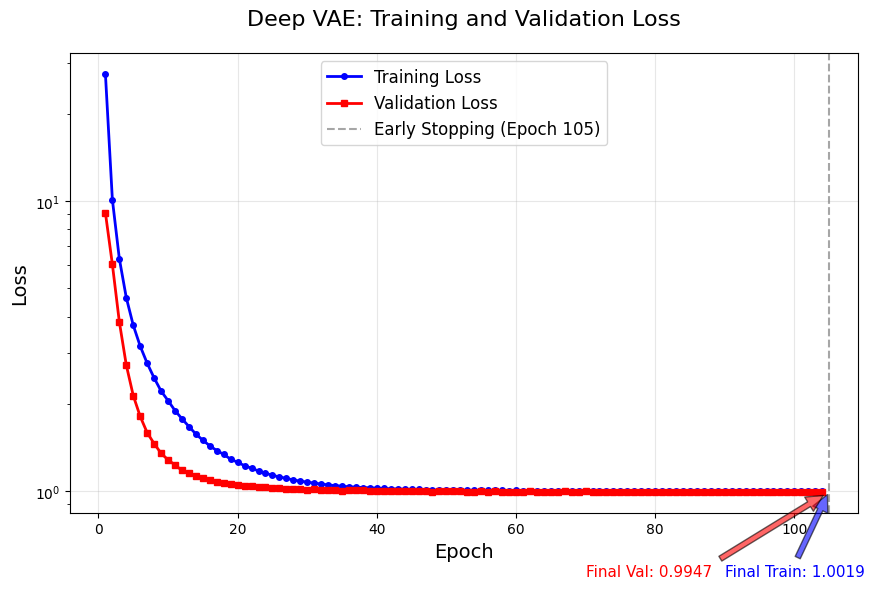

In [5]:
# Data from the training log


#Early Stopping Epoch
ese = 105

epochs = list(range(1, ese, 1))  # From 0 to 104 in steps of 1
train_loss = [
    27.4299, 10.1214, 6.3352, 4.6478, 3.7327, 3.1616, 2.7611, 2.4568, 2.2142, 2.0522,
    1.8962, 1.7769, 1.6705, 1.5738, 1.4985, 1.4336, 1.3806, 1.3390, 1.2888, 1.2577,
    1.2239, 1.1998, 1.1738, 1.1542, 1.1339, 1.1200, 1.1068, 1.0933, 1.0829, 1.0752,
    1.0660, 1.0585, 1.0514, 1.0449, 1.0406, 1.0353, 1.0325, 1.0291, 1.0273, 1.0238,
    1.0217, 1.0187, 1.0172, 1.0155, 1.0145, 1.0138, 1.0127, 1.0099, 1.0077, 1.0081,
    1.0079, 1.0078, 1.0073, 1.0067, 1.0062, 1.0068, 1.0056, 1.0056, 1.0052, 1.0054,
    1.0051, 1.0050, 1.0051, 1.0048, 1.0049, 1.0044, 1.0046, 1.0048, 1.0038, 1.0039,
    1.0043, 1.0038, 1.0037, 1.0041, 1.0033, 1.0031, 1.0027, 1.0027, 1.0028, 1.0026,
    1.0026, 1.0028, 1.0022, 1.0021, 1.0023, 1.0020, 1.0021, 1.0020, 1.0020, 1.0019,
    1.0019, 1.0021, 1.0017, 1.0018, 1.0022, 1.0019, 1.0014, 1.0016, 1.0018, 1.0018,
    1.0019, 1.0018, 1.0018, 1.0019
]

val_loss = [
    9.1085, 6.0527, 3.8363, 2.7212, 2.1358, 1.8099, 1.5911, 1.4588, 1.3509, 1.2823,
    1.2310, 1.1793, 1.1519, 1.1281, 1.1068, 1.0896, 1.0770, 1.0683, 1.0608, 1.0534,
    1.0421, 1.0417, 1.0342, 1.0314, 1.0259, 1.0238, 1.0184, 1.0182, 1.0154, 1.0123,
    1.0144, 1.0076, 1.0074, 1.0096, 1.0020, 1.0063, 1.0110, 1.0061, 1.0039, 1.0047,
    0.9991, 1.0008, 1.0029, 1.0007, 1.0011, 1.0001, 0.9998, 0.9972, 0.9976, 0.9979,
    0.9978, 0.9980, 0.9965, 0.9957, 0.9979, 0.9963, 0.9976, 0.9968, 0.9966, 0.9955,
    0.9961, 0.9975, 0.9955, 0.9952, 0.9954, 0.9962, 0.9991, 0.9966, 0.9950, 0.9982,
    0.9966, 0.9950, 0.9970, 0.9966, 0.9967, 0.9966, 0.9958, 0.9958, 0.9954, 0.9958,
    0.9956, 0.9959, 0.9941, 0.9938, 0.9952, 0.9958, 0.9945, 0.9959, 0.9938, 0.9960,
    0.9953, 0.9949, 0.9950, 0.9945, 0.9954, 0.9953, 0.9946, 0.9948, 0.9949, 0.9947,
    0.9945, 0.9947, 0.9947, 0.9947
]


print('len(epochs),len(train_loss),len(val_loss): ',len(epochs),len(train_loss),len(val_loss))

# Create the plot
plt.style.use('default')
plt.figure(figsize=(9, 6))
plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

# Add early stopping indicator
plt.axvline(x=ese, color='gray', linestyle='--', alpha=0.7, label=f'Early Stopping (Epoch {ese})')

# Customize the plot
plt.title('Deep VAE: Training and Validation Loss', fontsize=16, pad=20)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visualization of small values

# Add annotations for final values
final_train = train_loss[-1]
final_val = val_loss[-1]
plt.annotate(f'Final Train: {final_train:.4f}', 
             xy=(ese, final_train), xytext=(90, 0.51),
             arrowprops=dict(facecolor='blue', shrink=0.05, alpha=0.6),
             fontsize=11, color='blue')

plt.annotate(f'Final Val: {final_val:.4f}', 
             xy=(ese, final_val), xytext=(70, 0.51),
             arrowprops=dict(facecolor='red', shrink=0.05, alpha=0.6),
             fontsize=11, color='red')

plt.tight_layout()
plt.show()